In [74]:
import pandas as pd
import numpy as np
from pathlib import Path
from src import data_processing, paths
import json


input_data_dir = paths.PROCESSED_DATA_DIR
input_data_path = input_data_dir / 'BARTER_DEALS_CLEAN.parquet'
df = pd.read_parquet(input_data_path)

# Comments
- Check whether the image attractiveness (branding quality) is predictive of applications
    - Creators zijn visueel ingesteld
- Remove zero apps: there was a bug in the app where Live deals were not visible. Therefore, remove them. 
- Alignment with Creators/influencers 
- How easy it is to capture the product in an image
- Number of pictures

Generally, for an influencer marketing platform, we should assume that creators assess the value proposition of the deals, so $attractiveness \approx \frac{perceived\_value}{perceived\_effort}$. 

To understand the popularity of a deal, we need to first control for confounders (to follow the _ceteris paribus_ clause (all else being equal)). For us, that is geographical location: some markets are well-developed and have more users, so they will garner more applicants. 

Holding the confounders constant, we should model the attractiveness through the value, cost, and effort

- (Perceived) value
    - Deal value
        - Interestingly, it is not significant in our analysis; also, we have to drop many rows without a deal value, leading to low $n$
    - Barter attractiveness
        - Creators are more interested in Bol giftcards than in some software, increasing the perceived value
- Effort
    - How strict are the requirements?
        - Only a story, or a reel, multiple TikToks? 

# General features

In [ ]:
df['created_at'] = pd.to_datetime(df['created_at'])
df['month'] = df['created_at'].dt.to_period('M')
df['week'] = df['created_at'].dt.to_period('W-MON')

df['log_apps'] = np.log1p(df['apps_after_7_days'])



# Content types
df['content_types_set'] = df['content_types'].apply(
    lambda x: set(y['name'] for y in x) if type(x) == np.ndarray else set())
df['content_types_list'] = [list(x) for x in df['content_types_set']]

# # Fine-grained locations
# df['company_locations_parsed'] = df['company_locations'].apply(lambda x: json.loads(x) if pd.notna(x) else pd.NA)
# df['city_set'] = df['company_locations_parsed'].apply(lambda x: frozenset([y.get('town_slug').lower() for y in x]) if isinstance(x, list) else pd.NA)
# df['province_set'] = df['company_locations_parsed'].apply(lambda x: frozenset([y.get('town').lower() for y in x]) if isinstance(x, list) else pd.NA)
# df['province_list'] = df['province_set'].apply(lambda x: list(x) if isinstance(x, frozenset) else pd.NA)

In [78]:
def intelligent_category_merge(df, target_col='apps_after_7_days', min_n=30, mean_tolerance=5.0):
    # 1. Prepare Data: Ensure sets are hashable for grouping
    df['combo_key'] = df['content_types_set'].apply(
        lambda x: frozenset(x) if isinstance(x, (set, list)) else frozenset())

    # 2. Calculate Stats for every unique combination
    stats = df.groupby('combo_key')[target_col].agg(
        ['count', 'mean']).reset_index()

    # 3. Define the "Anchors" (Large Groups) and "Orphans" (Small Groups)
    anchors = stats[stats['count'] >= min_n].copy()
    orphans = stats[stats['count'] < min_n].copy()

    # Dictionary to map {Orphan_Set -> Best_Anchor_Set}
    merge_map = {}

    # 4. Iterate through every Orphan to find a home
    for _, orphan in orphans.iterrows():
        orphan_set = orphan['combo_key']
        orphan_mean = orphan['mean']

        best_anchor = None
        best_score = -1
        min_mean_diff = float('inf')

        # Check against all Anchors
        for _, anchor in anchors.iterrows():
            anchor_set = anchor['combo_key']
            anchor_mean = anchor['mean']

            # --- CRITERIA 1: Intersection ---
            intersect_len = len(orphan_set.intersection(anchor_set))
            if intersect_len < 1:
                continue  # No shared DNA, skip

            # --- CRITERIA 2: Mean Similarity ---
            # If the orphan is tiny (N<5), the mean is noisy, so we trust the tag overlap more.
            # If the orphan is decent (N>5), we enforce the mean check strictly.
            mean_diff = abs(orphan_mean - anchor_mean)

            if mean_diff > mean_tolerance:
                continue  # Behave too differently, skip

            # --- SCORING: Find the "Best" Fit ---
            # Priority 1: Maximize Overlap (Jaccard-ish)
            # Priority 2: Minimize Mean Difference (Tie-breaker)
            if intersect_len > best_score:
                best_score = intersect_len
                min_mean_diff = mean_diff
                best_anchor = anchor_set
            elif intersect_len == best_score:
                if mean_diff < min_mean_diff:
                    min_mean_diff = mean_diff
                    best_anchor = anchor_set

        # If we found a parent, record the mapping
        if best_anchor:
            merge_map[orphan_set] = best_anchor
        else:
            merge_map[orphan_set] = "Other_Rare"  # No suitable parent found

    # 5. Apply the Mapping
    # Anchors map to themselves (convert frozenset to string for readability)
    anchor_map = {k: sorted(list(k))[0] if len(
        k) == 1 else f"Mix: {sorted(list(k))[0]}+" for k in anchors['combo_key']}

    # Orphans map to their new parent's label
    final_map = {}
    for k, v in merge_map.items():
        if v == "Other_Rare":
            final_map[k] = "Other_Rare"
        else:
            final_map[k] = anchor_map[v]  # Use the readable name of the anchor

    # Merge the Anchor map in so looking up anchors works too
    final_map.update(anchor_map)

    return df['combo_key'].map(final_map).fillna("Other_Rare")


df['content_category_smart'] = intelligent_category_merge(df)

In [117]:
df.groupby('content_category_consolidated')[
    'apps_after_7_days'].agg(['count', 'mean', 'std'])

,count,mean,std
content_category_consolidated,,,
Activities,102,7.323529,24.889523
Activities+Experiences,422,7.189573,16.199237
Activities+Sport,150,8.200000,15.417675
Animals,59,7.593220,12.650635
Beauty,414,10.717391,16.323748
Beauty+Fashion,117,14.025641,21.988030
Beauty+Fashion+,194,19.680412,35.185238
Beauty+Lifestyle,91,10.714286,16.789736
Beauty+Lifestyle+,419,16.324582,26.263381


In [120]:
# 1. Look inside the 'Other_Rare' bucket
rare_df = df[df['content_category_consolidated'] == 'Other_Unmatched']

# 2. See which specific tag combinations are the "Superstars"
# We aggregate by the raw tags to find the hidden gems
rare_stats = rare_df.groupby(rare_df['content_types_list'].apply(tuple))['apps_after_7_days'].agg(
    ['count', 'mean', 'max']
).sort_values(by='mean', ascending=False)

rare_stats

,count,mean,max
content_types_list,,,
"(Gaming,)",5,13.000000,51
"(Movie,)",2,6.000000,12
"(Nightlife,)",3,4.333333,13
"(Finance,)",13,2.384615,9
"(Music,)",6,2.000000,4
"(Photography,)",9,1.666667,13
(),11,1.181818,13
"(Nightlife, Music)",4,1.000000,2
"(Photography, Movie)",2,0.000000,0


In [121]:
# Define location variables
df['accepted_countries_set'] = [set(x) for x in df['accepted_countries']]


df['company_locations_parsed'] = df['company_locations'].apply(
    lambda x: json.loads(x) if pd.notna(x) else pd.NA)


# 1. Update city_set (town_slug)
df['city_set'] = df['company_locations_parsed'].apply(
    lambda x: frozenset([
        y.get('town_slug').lower()
        for y in x
        if y.get('town_slug') and isinstance(y.get('town_slug'), str)
    ]) if isinstance(x, list) else pd.NA
)

# 2. Update province_set (town)
df['province_set'] = df['company_locations_parsed'].apply(
    lambda x: frozenset([
        y.get('town').lower()
        for y in x
        if y.get('town') and isinstance(y.get('town'), str)
    ]) if isinstance(x, list) else pd.NA
)

df['province_list'] = df['province_set'].apply(
    lambda x: list(x) if isinstance(x, frozenset) else pd.NA)

In [126]:
# Var to control for monthly growth
monthly_sums = df.groupby('month')['apps_after_7_days'].sum().reset_index()
monthly_sums.rename(
    columns={'apps_after_7_days': 'monthly_sums'}, inplace=True)
df = pd.merge(df, monthly_sums, on='month', how='left')


df['rest_monthly_sums'] = df['monthly_sums'] - df['apps_after_7_days']
df['log_rest_of_platform'] = np.log1p(df['rest_monthly_sums'])

MergeError: Passing 'suffixes' which cause duplicate columns {'monthly_sums_x'} is not allowed.

# Data cleaning

In [130]:
import pandas as pd
from functools import wraps

# --- Logging Tool (Decorator) ---


def log_step(func):
    """
    A decorator that prints the shape of the dataframe before and after 
    a function execution, effectively tracking data loss.
    """
    @wraps(func)
    def wrapper(df, *args, **kwargs):
        start_len = len(df)
        result_df = func(df, *args, **kwargs)
        end_len = len(result_df)
        diff = start_len - end_len
        pct_lost = (diff / start_len * 100) if start_len > 0 else 0

        print(f"[{func.__name__:<25}] Start: {start_len:<6} | End: {end_len:<6} | Dropped: {diff:<5} ({pct_lost:.1f}%)")
        return result_df
    return wrapper

# --- Atomic Cleaning Steps ---


@log_step
def start_date(df, start_date):
    return df[df['month'] > start_date]


@log_step
def filter_incomplete_weeks(df):
    cutoff_date = df['created_at'].max() - pd.Timedelta(days=14)
    return df[df['created_at'] < cutoff_date].copy()


# @log_step
# def filter_low_n_categories(df, min_observations=50):
#     counts = df['first_content_type'].value_counts()
#     valid_categories = counts[counts >= min_observations].index
#     return df[df['first_content_type'].isin(valid_categories)].copy()

# @log_step
# def filter_low_n_categories(df, min_observations=50):
#     counts = df['content_types_list'].value_counts()
#     valid_categories = counts[counts >= min_observations].index
#     return df[df['content_types_list'].isin(valid_categories)].copy()

@log_step
def filter_low_n_categories(df, min_observations=50):
    counts = df['content_category_consolidated'].value_counts()
    valid_categories = counts[counts >= min_observations].index
    return df[df['content_category_consolidated'].isin(valid_categories)].copy()


@log_step
def filter_dead_high_volume_deals(df, floor=30):
    # Logic: we set the start date as deal_created/deal_live- but it might have been taken offline, and put online at a later point
    # That means it would not garner any apps_after_7_days, but would have a significant number of total apps
    # If this is the case, it is not a representative datapoint
    condition = (df['applicants_applications_count'] >
                 floor) & (df['apps_after_7_days'] == 0)
    return df[~condition].copy()


@log_step
def filter_archived(df):
    return df[df['status'] != 'archived'].copy()


@log_step
def filter_partners(df, partner_ids_to_remove):
    return df[~df['legacy_partner_id'].isin(partner_ids_to_remove)].copy()


@log_step
def filter_languages(df, languages_to_remove):
    return df[~df['deal_language'].isin(languages_to_remove)].copy()


@log_step
def filter_for_deal_value(df, min_deal_value, max_deal_value):
    if min_deal_value == 'skip':
        return df
    return df[(df.deal_value > min_deal_value) & (df.deal_value < max_deal_value)]


@log_step
def min_apps_after_seven_days(df, min_apps_after_7_days):
    # Sets a minimum for the KPI, with the idea of modelling the non-zero deals. Set to -1 to ignore
    return df[df['apps_after_7_days'] > min_apps_after_7_days].copy()


@log_step
def min_apps_total(df, min_apps):
    return df[df['applicants_applications_count'] >= min_apps].copy()


@log_step
def filter_invalid_deals(df):
    """
    Removes deals that were structurally incapable of receiving applications.
    This avoids Truncation Bias by filtering on INPUTS (status), not OUTPUTS (apps).
    """

    # Date Check
    has_start_date = df['go_live_at'].notna()

    # Content Check (Optional but recommended based on your finding)
    has_images = df['images'].notna()

    # Combine
    valid_deals = has_start_date & has_images

    return df[valid_deals].copy()


@log_step
def max_follower_requirement(df, max_follower_requirement):
    return df[df['min_social_media_followers'] < max_follower_requirement]


@log_step
def log_transform_cols(df, cols):
    """
    Applies log1p transformation to specified columns.
    Creates new columns with 'log_' prefix to preserve original data.
    """
    # Create a copy to avoid SettingWithCopyWarning on slice
    df = df.copy()

    for col in cols:
        if col in df.columns:
            # log1p calculates log(1 + x), safe for 0 values
            df[f'log_{col}'] = np.log1p(df[col])
        else:
            print(
                f"⚠️ Warning: Column '{col}' not found, skipping log transform.")

    return df

# Note: Winsorizing is a transformation, not a filter, so it usually doesn't change row count.
# We can skip the @log_step here or create a different logger for transformations.


def apply_transformations(df):
    df = df.copy()
    # Apply winsorization logic here (assuming function exists)
    # df['apps_after_7_days_clean'] = ...

    df['social_requirement_type_id'] = df['social_requirement_type_id'].astype(
        int).astype(str)
    return df

# --- The Pipeline ---


def run_cleaning_pipeline(raw_df, config):
    print(f"{'STEP':<30} {'START':<6}   {'END':<6}   {'DROPPED':<5} {'% LOSS'}")
    print("-" * 75)

    clean_df = (
        raw_df
        .pipe(start_date, start_date=config['START_DATE'])
        .pipe(filter_low_n_categories, min_observations=config["MIN_CATEGORY_OBSERVATIONS"])
        .pipe(filter_incomplete_weeks)
        .pipe(filter_dead_high_volume_deals, floor=config["diff_total_apps_7_days_floor"])
        .pipe(filter_archived)
        .pipe(max_follower_requirement, max_follower_requirement=config['max_follower_requirement'])
        .pipe(min_apps_after_seven_days, min_apps_after_7_days=config['min_apps_after_7_days'])
        .pipe(min_apps_total, min_apps=config['MIN_APPS_TOTAL'])
        .pipe(filter_invalid_deals)
        .pipe(filter_partners, partner_ids_to_remove=config["PARTNER_IDS_TO_REMOVE"])
        .pipe(filter_languages, languages_to_remove=config["DEAL_LANGUAGES_TO_REMOVE"])
        # .pipe(filter_for_deal_value, min_deal_value=config["MIN_DEAL_VALUE"], max_deal_value=config["MAX_DEAL_VALUE"])
        .pipe(log_transform_cols, cols=config['LOG_TRANSFORM_COLS'])
    )

    # Apply non-filtering transformations at the end (usually these don't drop rows)
    # clean_df = apply_transformations(clean_df)

    return clean_df

In [131]:
# 1. Define your configuration dictionary
cleaning_config = {
    # "START_DATE": "2025-05",
    "START_DATE": "2025-04",
    # "MIN_CATEGORY_OBSERVATIONS": 20,
    "MIN_CATEGORY_OBSERVATIONS": 30,
    "PARTNER_IDS_TO_REMOVE": [85, 4],
    # "PARTNER_IDS_TO_REMOVE": [],
    # "DEAL_LANGUAGES_TO_REMOVE": ['de'],
    "DEAL_LANGUAGES_TO_REMOVE": [],
    "diff_total_apps_7_days_floor": 10,
    # Requiring min of 1 app improves R2, but might filter sincerely bad deals
    'MIN_APPS_TOTAL': 0,
    'min_apps_after_7_days': -1,
    "MIN_DEAL_VALUE": 0,
    "MAX_DEAL_VALUE": 1000,
    "LOG_TRANSFORM_COLS": ['deal_value'],
    "max_follower_requirement": 25000
}


clean_df = run_cleaning_pipeline(df, cleaning_config)

STEP                           START    END      DROPPED % LOSS
---------------------------------------------------------------------------
[start_date               ] Start: 6472   | End: 3523   | Dropped: 2949  (45.6%)
[filter_low_n_categories  ] Start: 3523   | End: 3355   | Dropped: 168   (4.8%)
[filter_incomplete_weeks  ] Start: 3355   | End: 3256   | Dropped: 99    (3.0%)
[filter_dead_high_volume_deals] Start: 3256   | End: 3205   | Dropped: 51    (1.6%)
[filter_archived          ] Start: 3205   | End: 3170   | Dropped: 35    (1.1%)
[max_follower_requirement ] Start: 3170   | End: 2990   | Dropped: 180   (5.7%)
[min_apps_after_seven_days] Start: 2990   | End: 2990   | Dropped: 0     (0.0%)
[min_apps_total           ] Start: 2990   | End: 2990   | Dropped: 0     (0.0%)
[filter_invalid_deals     ] Start: 2990   | End: 2547   | Dropped: 443   (14.8%)
[filter_partners          ] Start: 2547   | End: 2466   | Dropped: 81    (3.2%)
[filter_languages         ] Start: 2466   | End: 2466 

In [85]:
# def get_granular_segment(row):
#     cities = row['city_set']      # This should be a frozenset/set
#     provinces = row['province_set'] # This should be a frozenset/set

#     # Safety check for NaNs
#     if pd.isna(cities): cities = set()
#     if pd.isna(provinces): provinces = set()

#     # TIER 1: The Big City (The "Core")
#     # .isdisjoint() returns False if they share ANY elements
#     if not cities.isdisjoint(BIG_CITIES):
#         return "1_Big_NL_Core"

#     # TIER 2: The Big Province (The "Ring")
#     # It failed the City check, so it's NOT a big city.
#     # Now check if it's inside one of the Big Provinces.
#     if not provinces.isdisjoint(BIG_PROVINCES):
#         return "1_Big_NL_Core"

#     return "2_Rest_of_NL"


# BIG_CITIES = {
#     'amsterdam', 'utrecht', 'breda'
# }

# BIG_PROVINCES = {
#     'noord-holland', 'zuid-holland', 'utrecht', 'noord-brabant'
# }

# def create_market_scope(row):
#     countries = row["accepted_countries_set"]

#     # TIER 1: The Core (Reference Candidate)
#     if "NLD" in countries:
#         return get_granular_segment(row) # Tier 1, 2, 3

#     # TIER 2: The Middle (Keep separate to preserve R2!)
#     if countries == {"BEL"}:
#         return "3_BEL_Only"

#     # TIER 3: The Rest (Group DEU, GBR, and others)
#     # The data shows they all perform poorly (-0.6 to -0.7). Grouping reduces noise.
#     return "Tier4_DACH_Intl"


# def create_market_scope(row):
#     countries = row["accepted_countries_set"]

#     # TIER 1: The Core (Reference Candidate)
#     if "NLD" in countries:
#         return "Tier1_NL_Core"

#     # TIER 2: The Middle (Keep separate to preserve R2!)
#     if countries == {"BEL"}:
#         return "Tier2_BEL_Only"

#     # TIER 3: The Rest (Group DEU, GBR, and others)
#     # The data shows they all perform poorly (-0.6 to -0.7). Grouping reduces noise.
#     return "Tier3_DACH_Intl"


# HUB_GROUP = {'noord-holland', 'utrecht', 'noord-brabant', 'zuid-holland'}

# def create_deal_physical_location(row):
#     # High-level exclusions
#     if row['deal_type'] == 'online': return 'online'
#     # if 'NLD' not in row['accepted_countries']: return 'not_NLD'

#     prov_list = row['province_list']

#     # # Single-province check for the "Big" ones
#     # if 'Zuid-Holland' in prov_list:
#     #     return 'Zuid-Holland'

#     # # Priority check (Noord-Holland as a special category regardless of list length)
#     # if 'Noord-Holland' in prov_list:
#     #     return 'contains_Noord-Holland'

#     # Group the other major hubs
#     if any(p in HUB_GROUP for p in prov_list):
#         return 'NL_Major_Hubs'


#     # Catch-all
#     return 'rest'

#     # cities = row['city']
#     # if 'Amsterdam' in cities:
#     #     return 'Amsterdam'


# # 1. Define your specific "Big City" targets
# BIG_CITIES = {'amsterdam', 'breda', 'utrecht'}

# # 2. Define the "Rich Provinces" (The Commuter Belt)
# HUB_PROVINCES = {'noord-holland', 'zuid-holland', 'utrecht', 'noord-brabant'}

# def create_granular_location(row):
#     # --- Global Filters ---
#     if row['deal_type'] == 'online': return 'online'
#     if 'NLD' not in row['accepted_countries']: return 'not_NLD'

#     # Load data
#     prov_list = row['province_list']
#     town_slugs = row['city_set'] # Assuming you have this from earlier

#     # --- TIER 1: The Urban Core ---
#     # Check if ANY of the towns in this deal are Big Cities
#     if any(slug in BIG_CITIES for slug in town_slugs):
#         return 'Tier_1_Big_City'

#     # --- TIER 2: The Commuter Belt ---
#     # It's NOT a big city, but is it in a Hub Province?
#     if any(p in HUB_PROVINCES for p in prov_list):
#         return 'Tier_2_Hub_Region'

#     # --- TIER 3: The Rest ---
#     return 'Tier_3_Periphery'

# 1. Define Hubs
# BIG_PROVINCES = {'noord-holland', 'zuid-holland', 'utrecht', 'noord-brabant'}
# Note: Since you found City and Province perform the same, we only need the province check!

# def create_market_scope(row):
#     countries = row.get("accepted_countries_set", set())

#     # --- NON-DUTCH MARKETS (Low Performance) ---
#     if "NLD" not in countries:
#         if countries == {"BEL"}:
#             return "Tier3_BEL_Only"
#         return "Tier4_DACH_Intl"

#     # --- DUTCH MARKET (NLD) ---

#     # 1. Online Deals (High Performance)
#     # Map them to the "Tier 1" bucket or keep distinct if you want to measure the "Physical Penalty"
#     if row['deal_type'] == 'online':
#         return "Tier1_NL_High_Potential" # Online performs like Hubs

#     # 2. Physical Deals - The Granular Split
#     provinces = row.get('province_set', frozenset())

#     # Check if it's in a Hub Province
#     if not provinces.isdisjoint(BIG_PROVINCES):
#         return "Tier1_NL_High_Potential" # Hubs perform like Online

#     # 3. The "Rest" (Physical, Non-Hub)
#     # This now purely captures "Rural Physical Deals" (The bad performers)
#     return "Tier2_NL_Rest_Physical"


# The "Hub" Provinces
# HUB_PROVINCES = {'noord-holland', 'utrecht', 'noord-brabant'}

# def create_market_scope(row):
#     countries = row.get("accepted_countries_set", set())
#     is_online = (row['deal_type'] == 'online')
#     accepts_intl = (row['accepts_international'] == True) # or len(countries) > 1

#     # --- 1. NON-DUTCH MARKETS (Low Performance) ---
#     if "NLD" not in countries:
#         if countries == {"BEL"}:
#             return "Tier4_BEL_Only"
#         return "Tier5_DACH_Intl"

#     # --- 2. DUTCH MARKET (NLD) ---

#     # CASE A: ONLINE DEALS
#     if is_online:
#         if accepts_intl:
#             # The "Super Tier" you identified (Significantly higher means)
#             return "Tier1_Online_International"
#         else:
#             # Good, but not "Export" level. Groups well with Physical Hubs.
#             return "Tier2_NL_High_Potential"

#     # CASE B: PHYSICAL DEALS
#     # We ignore 'accepts_intl' here because you found no significant difference
#     provinces = row.get('province_set', frozenset())

#     # Check if it's in a Hub Province
#     if not provinces.isdisjoint(HUB_PROVINCES):
#         return "Tier2_NL_High_Potential" # Groups with Domestic Online

#     # The "Penalty Box" (Rural Physical)
#     return "Tier3_NL_Rest_Physical"

# Apply the new scope
# clean_df['market_scope_refined'] = clean_df.apply(create_market_scope_final, axis=1)




In [132]:
# The "Hub" Provinces
HUB_PROVINCES = {'noord-holland', 'utrecht', 'noord-brabant'}


def create_market_scope(row):
    # SAFELY get countries (handle pd.NA or None)
    countries = row.get("accepted_countries_set")
    if not isinstance(countries, (set, frozenset)):
        countries = set()

    is_online = (row['deal_type'] == 'online')
    accepts_intl = (row['accepts_international'] == True)

    # --- 1. NON-DUTCH MARKETS (Low Performance) ---
    if "NLD" not in countries:
        if countries == {"BEL"}:
            return "Tier4_BEL_Only"
        return "Tier5_DACH_Intl"

    # --- 2. DUTCH MARKET (NLD) ---

    # CASE A: ONLINE DEALS
    if is_online:
        if accepts_intl:
            return "Tier1_Online_International"
        else:
            return "Tier2_NL_High_Potential"

    # CASE B: PHYSICAL DEALS
    # SAFELY get provinces
    provinces = row.get('province_set')

    # CRITICAL FIX: explicit type check before method call
    if not isinstance(provinces, (set, frozenset)):
        provinces = frozenset()

    # Now .isdisjoint() is safe to call
    if not provinces.isdisjoint(HUB_PROVINCES):
        return "Tier2_NL_High_Potential"

    return "Tier3_NL_Rest_Physical"



def compute_competitor_density(input_df):
    df = input_df.copy()
    # Count deals per category per day
    df['date'] = df['created_at'].dt.date
    daily_counts = df.groupby(['date', 'content_category_smart']).size(
    ).reset_index(name='category_daily_count')

    # Merge back (subtract 1 so the deal doesn't count itself)
    df = df.merge(daily_counts, on=['date', 'content_category_smart'])
    df['competitor_density'] = df['category_daily_count'] - 1

    return df



def feature_engineering(ratings_df, GROUPS, CATS, CONTS, BINS, CLUSTER_COL, SCORE_VAR, TARGET):
    df = ratings_df.copy()

    # Log of applications
    df['log_apps'] = np.log1p(df['apps_after_7_days'])

    df['content_types_str'] = [
        '_'.join(x) for x in df['content_types_list']]

    # Compute offset parameter
    monthly_means = df.groupby('month')[TARGET].transform('mean')
    df['log_offset'] = np.log(monthly_means + 0.01)

    # Market scope
    df.loc[:, 'nr_of_accepted_countries'] = [
        len(x) for x in df['accepted_countries']]
    df.loc[:, 'includes_NL'] = [['NLD'] in x for x in df.accepted_countries]

    df['market_scope'] = df.apply(create_market_scope, axis=1)
    df = compute_competitor_density(df)
    df.loc[:,'log_nr_of_accepted_countries'] = np.log1p(df.loc[:,'nr_of_accepted_countries'])

    # Description length
    df['log_requirements_length'] = np.log1p(
        df['creators_requirement'].str.len())
    # df['desc_length'] = df['deal_text'].str.len()

    # Deals that have status live are known to be successful- that's why they have not been deleted. Therefore, we need to control
    df['is_live'] = df['status'] == 'live'

    df['strict_follower_requirement'] = df.min_social_media_followers > 4000



    # Take mean of duplicate deal texts
    if 'dimension_name' in ratings_df.columns:
        CATS_dict = {x: 'first' for x in CATS + BINS + [CLUSTER_COL]}
        CONT_dict = {x: 'mean' for x in [
            TARGET] + CONTS + [SCORE_VAR] + ['log_offset']}
        agg_dicts = CONT_dict | CATS_dict

        df = df.groupby(['deal_text'] + ['dimension_name'] +
                        GROUPS).agg(agg_dicts).reset_index()

    return df

In [138]:
# 2. Define Variables (Move these to your config.yaml later!)
GROUPS = ['model_name', 'prompt_id']

###
TARGET = 'apps_after_7_days'
TARGET = 'log_apps'
# TARGET = 'apps_after_7_days_clean'
# TARGET = 'apps_after_7_days_OLD'
# TARGET = 'applicants_applications_count'


###
# Categorical variables
CATS = []
CATS = ['market_scope', 'first_content_type']
CATS = ['market_scope', 'content_category_consolidated']

# ['includes_NL', 'deal_language', 'social_requirement_type_id', 'deal_type', 'month', 'content_types_str']


CONTS = []
CONTS = ['log_rest_of_platform', 'competitor_density']
# CONTS = ['log_rest_of_platform', 'log_min_followers', 'nr_of_accepted_countries', 'log_deal_value', 'log_desc_length']



###
# Binary variables
BINS = []
BINS = ['is_live']
BINS = ['is_live', 'strict_follower_requirement']
# BINS = ['accepts_international', 'deal_text_has_emoji', 'deal_type_physical', 'is_august']

###
# LLM evaluation variable
SCORE_VAR = 'mean_rating'

###
# Column for Clustered standard errors
CLUSTER_COL = 'partner_id'


# Feature engineering
feature_config = {
    "GROUPS": GROUPS,
    "CONTS": CONTS,
    "CATS": CATS,
    "BINS": BINS,
    "CLUSTER_COL": CLUSTER_COL,
    "SCORE_VAR": SCORE_VAR,
    "TARGET": TARGET
}


# Features
model_df = feature_engineering(
    clean_df, GROUPS, CATS, CONTS, BINS, CLUSTER_COL, SCORE_VAR, TARGET)




In [ ]:
# Other features

# Significant at 0.037, insufficient to keep it in, but I should better capture this in the Market Scope Tiers
# model_df['deal_type_physical'] = model_df['deal_type'] == 'physical'


# model_df['deal_text_has_emoji'] = model_df['deal_text'].apply(
#     lambda x: emoji.emoji_count(x) > 0)

# model_df['log_min_followers'] = np.log1p(model_df.min_social_media_followers)



# # Create the "Hustle Window" (Last 5 days + First 5 days)
# # This captures the psychological "New Month" or "Rent Due" effect
# dom = model_df['created_at'].dt.day
# model_df['is_rent_week'] = dom.apply(lambda x: 1 if (x >= 25 or x <= 5) else 0)


# em-dash indicates AI generated
# Not significant
# has_em_dash = model_df['deal_text'].str.contains('—') | model_df['deal_title'].str.contains('—') | model_df['creators_requirement'].str.contains('—')
# model_df['has_em_dash'] = has_em_dash

# contains_euro = model_df['deal_text'].str.contains('€') | model_df['deal_title'].str.contains('€') | model_df['creators_requirement'].str.contains('€')
# model_df['contains_euro'] = contains_euro


# model_df['is_august'] = model_df['month'] == '2025-08'

# model_df['normalized_days_since_start'] = model_df['days_since_start'] - \
#     min(model_df['days_since_start'])
# model_df['log_days_since_start'] = np.log1p(
#     model_df['normalized_days_since_start'])

# Models

In [134]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from typing import List, Optional


def build_base_predictor_matrix(
    df: pd.DataFrame,
    num_predictors: List[str],  # e.g., ['log_deal_value']
    bin_predictors: List[str],  # e.g., ['accepts_international']
    # e.g., ['first_content_type', 'social_requirement_type_id']
    cat_predictors: List[str],
    drop_na: bool = True
) -> Optional[pd.DataFrame]:
    """
    Builds a clean design matrix (X) for OLS regression.

    Handles:
    - Numeric/Binary columns
    - One-hot encoding for Categoricals (with drop_first=True)
    - Constant term (Intercept)
    - Infinity/NaN checks
    - Rank deficiency check
    """

    # 1. Create a working copy to avoid SettingWithCopy warnings
    #    We only select the columns we need to prevent shape mismatch later
    needed_cols = num_predictors + bin_predictors + cat_predictors
    X = df[needed_cols].copy()

    # 2. Safety: Handle Infinite values (common with log transformations)
    #    Replace -inf/inf with NaN so they are caught in the next step
    X.replace([np.inf, -np.inf], np.nan, inplace=True)

    # 3. Safety: Drop NaNs
    if drop_na:
        original_len = len(X)
        X = X.dropna()
        dropped_count = original_len - len(X)
        if dropped_count > 0:
            print(
                f"ℹ️ Dropped {dropped_count} rows containing missing or infinite values.")

    if X.empty:
        print("❌ Error: DataFrame is empty after cleaning.")
        return None

    predictor_parts = []

    # 4. Process Numeric & Binary
    #    Ensure binary cols are actual integers (0/1)
    if num_predictors or bin_predictors:
        X_num = X[num_predictors + bin_predictors].copy()
        for col in bin_predictors:
            X_num[col] = X_num[col].astype(int)
        predictor_parts.append(X_num)

    # 5. Process Categorical (One-Hot Encoding)
    if cat_predictors:
        # Force to string first to ensure categories are treated as discrete
        X_cat_subset = X[cat_predictors].astype(str)

        # drop_first=True is CRITICAL for OLS to avoid the "Dummy Variable Trap"
        # (perfect multicollinearity between dummies and the intercept)
        X_dummies = pd.get_dummies(X_cat_subset, drop_first=True, dtype=int)
        predictor_parts.append(X_dummies)

    # 6. Combine and Add Constant
    if not predictor_parts:
        print("❌ Error: No predictors provided.")
        return None

    X_final = pd.concat(predictor_parts, axis=1)

    # Add Intercept (Beta_0)
    X_final = sm.add_constant(X_final)

    # 7. Rank Check (Multicollinearity)
    #    If rank < number of columns, the matrix is singular (math breaks)
    if np.linalg.matrix_rank(X_final.values) < X_final.shape[1]:
        print("⚠️ Warning: Design matrix is rank-deficient. You have perfect multicollinearity.")
        print("   Check if one variable is a linear combination of others (e.g., 'is_male' vs 'is_female').")

    return X_final

## OLS

In [139]:
# model_df = model_df[model_df['market_scope'] != 'Other_Local']


X = build_base_predictor_matrix(
    df=model_df,
    num_predictors=CONTS,  # e.g., ['log_deal_value']
    bin_predictors=BINS,  # e.g., ['accepts_international']
    # e.g., ['first_content_type', 'social_requirement_type_id']
    cat_predictors=CATS,
    drop_na=True
)

y = model_df.loc[X.index, TARGET]

# model = sm.OLS(y, X).fit(cov_type='HC3')

model = sm.OLS(y, X).fit(cov_type='cluster', cov_kwds={
    'groups': model_df.loc[X.index, 'partner_id']})

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               log_apps   R-squared:                       0.274
Model:                            OLS   Adj. R-squared:                  0.263
Method:                 Least Squares   F-statistic:                     24.84
Date:                Fri, 13 Feb 2026   Prob (F-statistic):          6.73e-111
Time:                        10:30:46   Log-Likelihood:                -3607.8
No. Observations:                2466   AIC:                             7288.
Df Residuals:                    2430   BIC:                             7497.
Df Model:                          35                                         
Covariance Type:              cluster                                         
===========================================================================================================================
                                                              coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------
const                                                      -1.7077      0.980     -1.742      0.081      -3.629       0.214
log_rest_of_platform                                        0.4710      0.112      4.198      0.000       0.251       0.691
competitor_density                                         -0.0480      0.014     -3.453      0.001      -0.075      -0.021
is_live                                                     0.2051      0.070      2.930      0.003       0.068       0.342
strict_follower_requirement                                -0.1914      0.067     -2.875      0.004      -0.322      -0.061
market_scope_Tier2_NL_High_Potential                       -0.2016      0.084     -2.412      0.016      -0.365      -0.038
market_scope_Tier3_NL_Rest_Physical                        -0.7380      0.132     -5.582      0.000      -0.997      -0.479
market_scope_Tier4_BEL_Only                                -0.9901      0.168     -5.886      0.000      -1.320      -0.660
market_scope_Tier5_DACH_Intl                               -1.2891      0.072    -17.808      0.000      -1.431      -1.147
content_category_consolidated_Activities+Experiences       -0.3334      0.260     -1.281      0.200      -0.843       0.177
content_category_consolidated_Activities+Sport             -0.0184      0.270     -0.068      0.946      -0.548       0.511
content_category_consolidated_Animals                      -0.0490      0.263     -0.186      0.852      -0.565       0.467
content_category_consolidated_Beauty                        0.6368      0.242      2.631      0.009       0.162       1.111
content_category_consolidated_Beauty+Fashion                0.9009      0.299      3.009      0.003       0.314       1.488
content_category_consolidated_Beauty+Fashion+               0.4521      0.273      1.656      0.098      -0.083       0.987
content_category_consolidated_Beauty+Lifestyle              0.0930      0.291      0.320      0.749      -0.477       0.663
content_category_consolidated_Beauty+Lifestyle+             0.4804      0.250      1.920      0.055      -0.010       0.971
content_category_consolidated_Beauty+UGC                    0.3871      0.300      1.292      0.196      -0.200       0.974
content_category_consolidated_Cooking+Food                  0.1857      0.338      0.550      0.582      -0.476       0.848
content_category_consolidated_Drinks+Food                   0.3209      0.242      1.324      0.186      -0.154       0.796
content_category_consolidated_Drinks+Lifestyle              0.3012      0.282      1.068      0.286      -0.252       0.854
content_category_consolidated_Entertainment                -0.3225      0.317     -1.018      0.309      -0

In [140]:
model_df.groupby('market_scope')['apps_after_7_days'].agg(['count', 'mean'])

,count,mean
market_scope,,
Tier1_Online_International,919,21.379761
Tier2_NL_High_Potential,783,14.615581
Tier3_NL_Rest_Physical,171,9.076023
Tier4_BEL_Only,76,8.763158
Tier5_DACH_Intl,517,4.230174


### Diagnostics

- Check if assumptions are violated

c:\Users\Wouter Barter\Documents\AI_thesis\venv312\Lib\site-packages\statsmodels\graphics\gofplots.py:1041: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


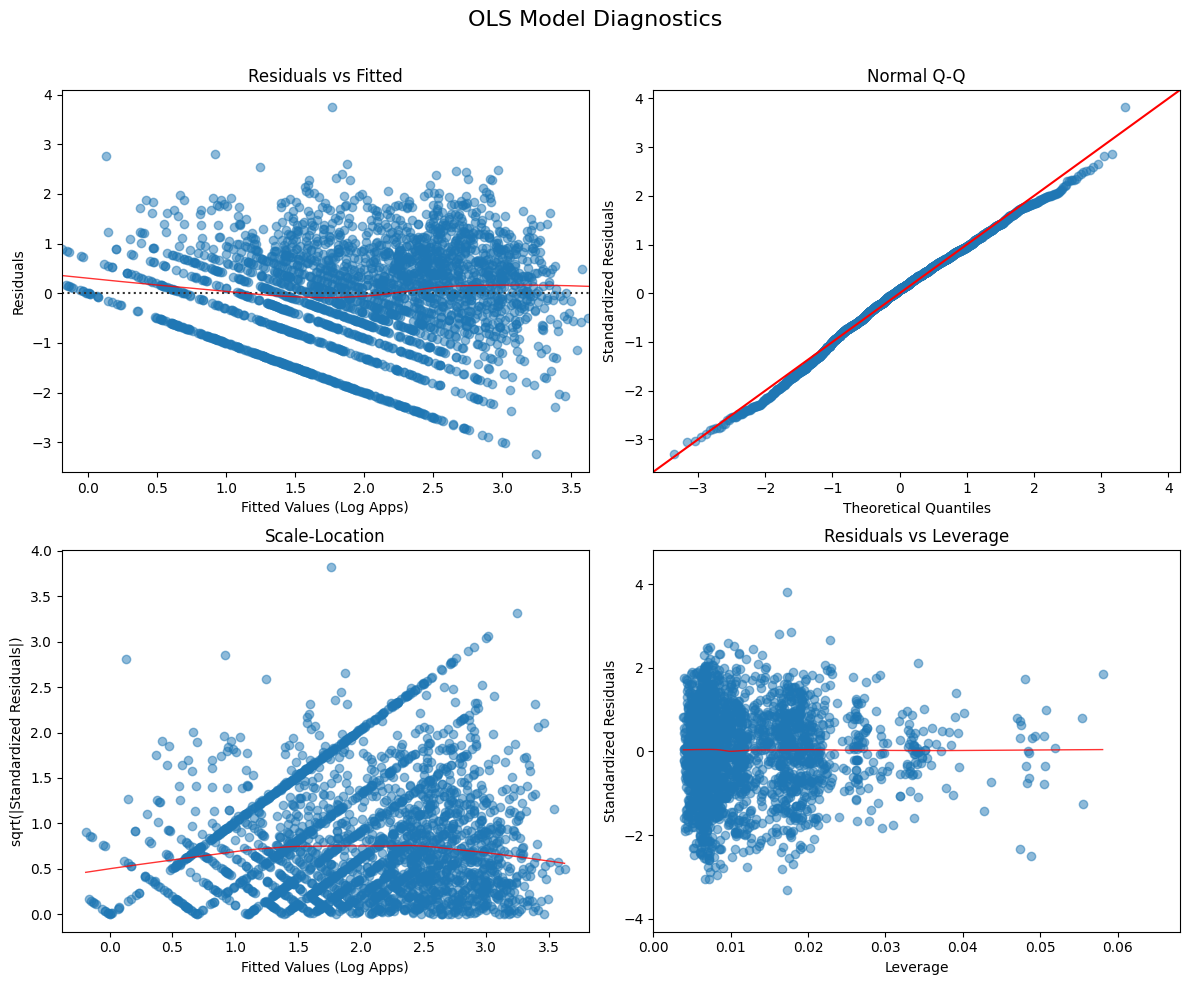

In [108]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.graphics.gofplots import ProbPlot
import numpy as np


def run_diagnostics(results):
    """
    Generates industry-standard diagnostic plots for OLS regression.
    Args:
        results: The fitted statsmodels OLS result object.
    """

    # 1. Basic Data Prep
    model_fitted_y = results.fittedvalues
    model_residuals = results.resid
    model_norm_residuals = results.get_influence().resid_studentized_internal
    model_abs_resid = np.abs(model_norm_residuals)
    model_leverage = results.get_influence().hat_matrix_diag
    model_cooks = results.get_influence().cooks_distance[0]

    # Set up the figure structure
    fig = plt.figure(figsize=(12, 10))
    fig.suptitle('OLS Model Diagnostics', fontsize=16)

    # --- Plot 1: Residuals vs Fitted ---
    # Checks for: Non-linearity and Heteroskedasticity
    ax1 = fig.add_subplot(2, 2, 1)
    sns.residplot(x=model_fitted_y, y=model_residuals,
                  lowess=True,
                  scatter_kws={'alpha': 0.5},
                  line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8}, ax=ax1)
    ax1.set_title('Residuals vs Fitted')
    ax1.set_xlabel('Fitted Values (Log Apps)')
    ax1.set_ylabel('Residuals')

    # --- Plot 2: Normal Q-Q ---
    # Checks for: Normality of residuals
    ax2 = fig.add_subplot(2, 2, 2)
    QQ = ProbPlot(model_norm_residuals)
    QQ.qqplot(line='45', alpha=0.5, color='#4C72B0', lw=1, ax=ax2)
    ax2.set_title('Normal Q-Q')
    ax2.set_xlabel('Theoretical Quantiles')
    ax2.set_ylabel('Standardized Residuals')

    # --- Plot 3: Scale-Location (Spread-Location) ---
    # Checks for: Homoscedasticity (Constant Variance)
    ax3 = fig.add_subplot(2, 2, 3)
    ax3.scatter(model_fitted_y, model_abs_resid, alpha=0.5)
    sns.regplot(x=model_fitted_y, y=model_abs_resid,
                scatter=False,
                ci=False,
                lowess=True,
                line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8}, ax=ax3)
    ax3.set_title('Scale-Location')
    ax3.set_xlabel('Fitted Values (Log Apps)')
    ax3.set_ylabel('sqrt(|Standardized Residuals|)')

    # --- Plot 4: Residuals vs Leverage ---
    # Checks for: Influential Outliers (Cook's Distance)
    ax4 = fig.add_subplot(2, 2, 4)
    ax4.scatter(model_leverage, model_norm_residuals, alpha=0.5)
    sns.regplot(x=model_leverage, y=model_norm_residuals,
                scatter=False,
                ci=False,
                lowess=True,
                line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8}, ax=ax4)

    # Add Cook's distance lines (Thresholds)
    # Ideally, points should be inside the dashed lines
    ax4.set_xlim(0, max(model_leverage) + 0.01)
    ax4.set_ylim(min(model_norm_residuals)-1, max(model_norm_residuals)+1)
    ax4.set_title('Residuals vs Leverage')
    ax4.set_xlabel('Leverage')
    ax4.set_ylabel('Standardized Residuals')

    # Optional: Draw Cook's distance lines for 0.5 and 1.0
    # (High influence thresholds)
    p = len(results.params)  # number of parameters

    def graph(formula, x_range, label=None):
        x = x_range
        y = formula(x)
        plt.plot(x, y, label=label, lw=1, ls='--', color='gray')

    # Cook's distance = 0.5 line
    graph(lambda x: np.sqrt((0.5 * p * (1 - x)) / x),
          np.linspace(0.001, max(model_leverage), 50), 'Cook\'s Dist=0.5')

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()


# Run it on your results
run_diagnostics(model)

- Check for which deals the predictions are good and for which they are bad

In [109]:
def inspect_model_errors(model_results, df, n=5):
    """
    Appends predictions and errors to the dataframe and displays extreme cases.
    """
    # 1. Add Predictions and Residuals to a copy of the data
    # Ensure indices align (statsmodels drops NaNs, so use the model's index)
    analysis_df = df.loc[model_results.fittedvalues.index].copy()

    # Get fitted values (Log Scale)
    analysis_df['log_predicted'] = model_results.fittedvalues
    analysis_df['log_actual'] = model_results.model.endog

    # Transform back to Real Count Scale (Exp - 1) for readability
    analysis_df['pred_apps'] = np.expm1(analysis_df['log_predicted']).round(1)
    analysis_df['actual_apps'] = np.expm1(
        analysis_df['log_actual']).astype(int)

    # Calculate Residual (Positive = Overperformed, Negative = Underperformed)
    analysis_df['error'] = analysis_df['actual_apps'] - \
        analysis_df['pred_apps']

    # 2. Display the "Overperformers" (Model predicted Low, Actual was High)
    print(f"\n--- TOP {n} OVERPERFORMERS (Unexplained Success) ---")
    cols_to_show = ['deal_title', 'deal_text',
                    'actual_apps', 'pred_apps', 'error']
    overperformers = analysis_df.sort_values(
        by='error', ascending=False).head(n)
    display(overperformers[cols_to_show])

    # 3. Display the "Underperformers" (Model predicted High, Actual was Low)
    print(f"\n--- TOP {n} UNDERPERFORMERS (Unexplained Failure) ---")
    underperformers = analysis_df.sort_values(
        by='error', ascending=True).head(n)
    display(underperformers[cols_to_show])

    return analysis_df


# Run the function
error_df = inspect_model_errors(model, model_df, n=40)


--- TOP 40 OVERPERFORMERS (Unexplained Success) ---


,deal_title,deal_text,actual_apps,pred_apps,error
659,TUI Early Booking Travel Video | €150,"<p>Maak&nbsp;een&nbsp;warme,&nbsp;dynamische&n...",244,4.8,239.2
660,Otrium Shopping Haul | €200 Voucher (NL),<p>It’s&nbsp;time&nbsp;to&nbsp;shop&nbsp;smart...,231,18.5,212.5
973,Content creator,1. Een vaste vergoeding van €500 per maand (na...,182,17.7,164.3
1998,Unbox Verloren & Retour Postpakketten t.w.v. €...,Een XL doos met verloren & retour postpakkette...,180,17.4,162.6
2108,Creëer jouw ultieme wellness moment met Rituals,Wij bieden de Rituals The Ritual of Karma Tria...,176,14.4,161.6
2092,Test de virale Sol de Janeiro Delicia Drench,Wij bieden de Sol de Janeiro Delicia Drench Bo...,168,13.3,154.7
422,Kledingset unboxing + passen,<p>Wij&nbsp;van&nbsp;Godlystore&nbsp;zoeken&nb...,154,14.7,139.3
2167,🍵 Matcha Ritual Set + €50 shoptegoed,🍵 Starter Kit Matcha White + €50 Store Credit\...,143,16.5,126.5
352,"Feel the glamour, taste Christmas!",Time to awaken the glamour queen (or king) in ...,132,11.4,120.6
628,Make content with our make-up products,Select 3 make-up products for free on our webs...,135,16.8,118.2



--- TOP 40 UNDERPERFORMERS (Unexplained Failure) ---


,deal_title,deal_text,actual_apps,pred_apps,error
905,[MALE] Record professional videos in our studio,"Hi! As the gifting season approaches, I’m crea...",3,30.7,-27.7
676,Black Espresso Cat Club,A 60 x 80 cm canvas ready to hang with this am...,2,28.5,-26.5
36,Ontvang een BUDLE TEE t.w.v. €150,<p>Ontvang&nbsp;een&nbsp;BUDLE&nbsp;TEE&nbsp;t...,3,29.3,-26.3
2251,Kabrita | Follow-on Milk 400g | On the way!,Title\nKabrita Follow-on Milk 400g – New and I...,0,24.7,-24.7
1281,Sauna Set Original Complete,This set is only good to use if you have a sau...,3,26.5,-23.5
2087,UGC of creating keepsake jewellery,DIY Affirmation Set for keepsake jewellery wit...,10,33.4,-23.4
1967,AMBASSADEUR VIDEO - VulpesBabycare,"We bieden een waardebon aan van 100,- euro die...",3,26.2,-23.2
1692,Fresk – Regenoutfit voor kids t.w.v. €120,Ontvang een complete regenoutfit van Fresk t.w...,6,28.6,-22.6
815,Coktail kunst,A high quality 60 x 80 cm artwork,5,27.5,-22.5
2268,Luxe Satin Setje + €25 & Meer!,<p>(NL:)&nbsp;Ben&nbsp;jij&nbsp;dol&nbsp;op&nb...,6,28.0,-22.0


In [461]:
error_df.applicants_applications_count - error_df.apps_after_7_days

17      80
35       0
46      16
48       4
90      39
        ..
7213    12
7242     2
7247     9
7248    16
7253     5
Length: 891, dtype: int64

In [462]:
error_df['diff_total_apps_seven_days'] = error_df.applicants_applications_count - \
    error_df.apps_after_7_days
error_df

,created_at,updated_at,deleted_at,id,legacy_partner_id,deal_title,deal_text,creators_requirement,hash_tags,status,...,includes_NL,log_desc_length,desc_length,content_types_str,log_predicted,log_actual,pred_apps,actual_apps,error,diff_total_apps_seven_days
17,2025-09-03 20:28:54.617718,2026-01-12 07:39:16.894227,NaT,01991144-a1d9-00c8-d237-1aba7afc7e63,1290.0,Vrouwelijk model Ralph Lauren kleding,Timeless Treasury is dé webshop voor exclusiev...,Zie vacaturetekst,,live,...,True,7.234898,1386,Fashion_Lifestyle_Luxury,3.084287,3.583519,20.9,35,14.1,80
35,2025-12-03 20:26:28.740180,2025-12-04 19:59:59.386526,NaT,019ae5e5-1c04-00c8-3082-56da8e8edcb3,3438.0,Verpleegkunde Gids,Een Gids in de verpleegkunde die bestaat uit +...,"1-2 video's op Instagram, Tiktok, Facebook.\n...","#nurses,#verpleegkundegids,#werkenindezorg,#Nu...",live,...,False,5.438079,229,Experiences,0.935691,0.693147,1.5,1,-0.5,0
46,2025-07-31 09:01:47.423425,2026-01-12 07:39:41.014016,NaT,01985fb7-561f-00c8-9275-2a7e0744a116,1695.0,5L Sangria met 5 vrienden!,Bij Tapasbar Plan B serveren wij een heerlijke...,Een foto of video van de sangria op je eigen I...,"#sangria,#tapas,#breda,#tapasbreda,#sangriabre...",live,...,True,5.683580,293,Drinks_Food,2.480703,2.302585,10.9,9,-1.9,16
48,2025-10-31 10:58:03.812674,2026-01-14 07:39:45.604536,NaT,019a39ea-d9a4-00c8-2181-4e23989682ac,2790.0,Trendy winddoek: upgrade jouw tuin,Een hoogwaardig winddoek voor in je tuin van V...,Een staande (1080x1920) video waarin jij laat ...,,draft,...,True,5.840642,343,Lifestyle,3.416503,2.484907,29.5,11,-18.5,4
90,2025-09-09 13:12:58.788668,2026-01-12 07:39:17.655011,NaT,01992e9b-aea4-00c8-f03d-ffdd3c477195,38.0,€50 Miniso Shoptegoed,Ontvang een waardebon van €50 om te besteden b...,– 1x Reel of TikTok van minimaal 30 seconden\n...,"#Miniso,#MinisoAlmere,#MinisoNetherlands",finished,...,True,5.937536,378,Lifestyle,3.050307,3.135494,20.1,22,1.9,39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7213,2025-11-05 12:29:47.674253,2026-01-30 23:03:50.274103,NaT,019a53fe-a11a-00c8-34ff-50f99e73802a,159.0,white chocolate marshmellow special,1 december we are launching our white chocolat...,1 tiktok video or 1 instagram reel or 3 instag...,,finished,...,True,5.505332,245,Drinks,2.461818,2.772589,10.7,14,3.3,12
7242,2025-08-13 18:46:10.999031,2026-02-01 04:00:03.073606,NaT,0198a4c1-0936-00c8-915a-55912c9fcd8d,977.0,Panterprint bikini,Ben jij klaar om de zomer stijlvol in te luide...,– 1x Instagram Reel video waarin je de bikini...,#emiliecollection,draft,...,True,5.948035,382,Fashion,2.287461,1.098612,8.8,2,-6.8,2
7247,2025-12-11 12:06:01.401968,2026-01-31 23:03:53.185628,NaT,019b0d4d-cdb9-00c8-a6ce-44563b468905,1101.0,Starterset Blokzeep,"Startersets met 1 shampoo bar, 1 bodybar en ee...",Morning routine video. Instagram reels of Tikt...,"#Blokzeep,#Startersset,#Frissestart",finished,...,True,4.787492,119,Beauty_UGC,3.001935,3.663562,19.1,37,17.9,9
7248,2025-12-15 13:37:59.411365,2026-01-31 23:03:53.777266,NaT,019b223b-7073-00c8-d4c1-c48769a62cf2,1889.0,"Carbonara, elke woensdag bij Spaghetteria",***GOED LEZEN: \nWelkom bij Spaghetteria!\n\nE...,***GOED LEZEN: \nContent richtlijnen\nWe vinde...,#carbonara,finished,...,True,6.342121,567,Drinks_Food,2.558249,1.791759,11.9,5,-6.9,16


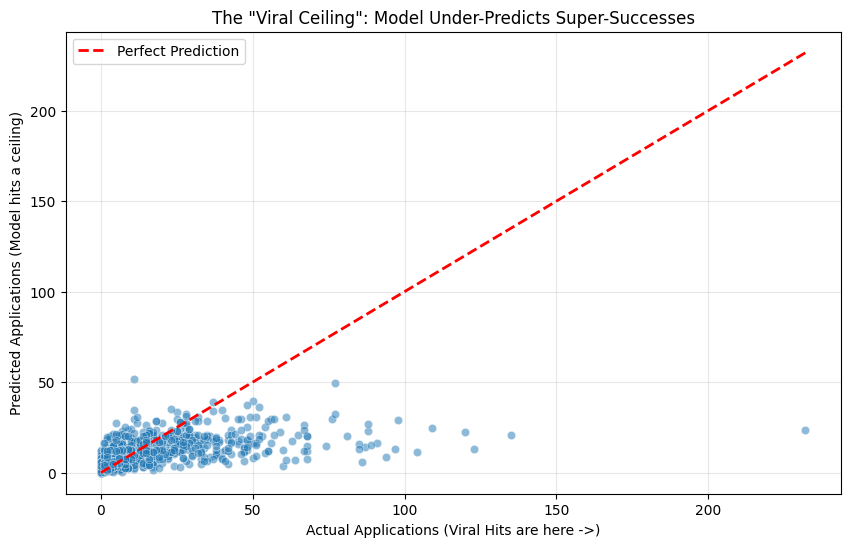

In [463]:
import matplotlib.pyplot as plt
import seaborn as sns


def plot_prediction_ceiling(model_results, df):
    # 1. Get data
    # Create a copy to avoid SettingWithCopyWarning
    plot_data = df.loc[model_results.fittedvalues.index].copy()
    plot_data['log_predicted'] = model_results.fittedvalues
    plot_data['log_actual'] = model_results.model.endog

    # 2. Convert back to counts for the plot (easier to see the 44 vs 244 gap)
    plot_data['pred_count'] = np.expm1(plot_data['log_predicted'])
    plot_data['actual_count'] = np.expm1(plot_data['log_actual'])

    # 3. Plot
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='actual_count', y='pred_count',
                    data=plot_data, alpha=0.5)

    # Add the "Perfect Prediction" line
    max_val = max(plot_data['actual_count'].max(),
                  plot_data['pred_count'].max())
    plt.plot([0, max_val], [0, max_val], 'r--',
             lw=2, label='Perfect Prediction')

    plt.title('The "Viral Ceiling": Model Under-Predicts Super-Successes')
    plt.xlabel('Actual Applications (Viral Hits are here ->)')
    plt.ylabel('Predicted Applications (Model hits a ceiling)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


plot_prediction_ceiling(model, model_df)

In [464]:
# Check the partners of the biggest underpredictions
misses = error_df.sort_values(by='error', ascending=False).head(20)
misses[['deal_title', 'deal_text', 'actual_apps', 'pred_apps', 'error']]

,deal_title,deal_text,actual_apps,pred_apps,error
2315,Otrium Shopping Haul | €200 Voucher (NL),<p>It’s&nbsp;time&nbsp;to&nbsp;shop&nbsp;smart...,231,23.4,207.6
2246,Make content with our make-up products,Select 3 make-up products for free on our webs...,135,20.8,114.2
1863,Shop & lunch bij Amsterdam The Style Outlets!,"🎁 Giftcard t.w.v. €100,- te besteden bij Amste...",123,13.1,109.9
5039,Receive €75 worth of Honey Balm lipcare,You’ll receive a curated lipcare bundle worth ...,120,22.6,97.4
1215,€100.- FASHIONOMI UTRECHT,Ben jij een tiktok creator die houd van fashio...,103,11.6,91.4
6231,DWRS Label zoekt UGC voor schoenencontent,Jij krijgt: \n\n\t•\t1 paar schoenen naar keuz...,94,8.8,85.2
6975,HELLO HOSHI | premium stainless steel jewelery!,Influencers ontvangen een HELLO HOSHI giftpakk...,109,24.5,84.5
6100,€150 Shoptegoed bij Pockies – Couch Couture,Ontvang €150 shoptegoed om te besteden bij Poc...,97,13.1,83.9
4962,Test en houdt deze geweldige Mini Projector!,Een geweldige HD mini Beamer van het topmerk P...,86,6.0,80.0
2584,Test de virale sensatie Tree Hut Cotton Candy,Wij bieden de Tree Hut Sugar Scrub Cotton Cand...,91,16.1,74.9


-------

# EDA

## Full DF

In [116]:
def consolidate_overlapping_anchors(df, min_n=15):
    # 1. Setup
    df['combo_key'] = df['content_types_set'].apply(
        lambda x: frozenset(x) if isinstance(x, (set, list)) else frozenset()
    )
    
    # 2. Identify Initial Anchors
    counts = df['combo_key'].value_counts()
    anchors = counts[counts >= min_n].index.tolist()
    
    # Sort anchors by size (Largest first) to ensure we merge Small -> Large
    anchors.sort(key=lambda x: counts[x], reverse=True)
    
    # Map starts as identity (everyone points to themselves)
    anchor_map = {k: k for k in anchors}
    
    # 3. The "Subset Absorber" Loop
    # We iterate through anchors to see if they can be swallowed by a larger anchor
    final_anchors = []
    
    for i, current in enumerate(anchors):
        absorbed = False
        
        # Check against all larger anchors we've already approved
        for larger in final_anchors:
            # RELATIONSHIP 1: Subset (Strict)
            # e.g. {'Cooking'} is subset of {'Food', 'Cooking'}
            is_subset = current.issubset(larger)
            
            # RELATIONSHIP 2: High Jaccard (Approximate)
            # e.g. {'Food', 'Drinks'} vs {'Food', 'Cooking'} -> Jaccard 0.33 (No Merge)
            # e.g. {'Food', 'Vegan'} vs {'Food'} -> Jaccard 0.5 (Maybe Merge?)
            intersection = len(current.intersection(larger))
            union = len(current.union(larger))
            jaccard = intersection / union if union > 0 else 0
            
            # CRITERIA: Merge if it's a strict subset OR extremely similar (>0.6)
            if is_subset or jaccard > 0.6:
                anchor_map[current] = larger # Point current to the larger parent
                absorbed = True
                break # Stop looking, we found a home
        
        if not absorbed:
            final_anchors.append(current)

    # 4. Now handle the Orphans (The N < 15 groups)
    # They point to the *remapped* final anchors
    orphans = counts[counts < min_n].index.tolist()
    
    for orphan in orphans:
        best_anchor = None
        best_score = -1.0
        
        for anchor in final_anchors: # Only compare against the Survivors
            intersection = len(orphan.intersection(anchor))
            union = len(orphan.union(anchor))
            if union == 0: continue
            
            score = intersection / union
            
            if score > best_score:
                best_score = score
                best_anchor = anchor
        
        if best_score > 0:
            anchor_map[orphan] = best_anchor
        else:
            anchor_map[orphan] = "Other_Unmatched"

    # 5. Create Readable Names
    # Helper to stringify the final keys
    def get_name(s):
        if isinstance(s, str): return s
        sl = sorted(list(s))
        return f"{'+'.join(sl[:2])}" + ("+" if len(sl) > 2 else "")

    # Apply the final cleaning
    return df['combo_key'].map(anchor_map).map(get_name)

# Run the consolidated cleaner
df['content_category_consolidated'] = consolidate_overlapping_anchors(df, min_n=15)

# Check the reduction
df['content_category_consolidated'].value_counts()

content_category_consolidated
Drinks+Food                  866
Food                         486
Lifestyle+UGC                458
Fashion                      429
Activities+Experiences       422
Beauty+Lifestyle+            419
Beauty                       414
UGC                          255
Lifestyle                    252
Beauty+Fashion+              194
Cooking+Food                 184
Lifestyle+Luxury             180
Mom                          152
Activities+Sport             150
Fashion+Lifestyle+           139
Experiences                  128
Beauty+Fashion               117
Mom+UGC                      108
Activities                   102
Entertainment+Experiences     97
Beauty+Lifestyle              91
Entertainment                 81
Tech                          77
Fashion+Lifestyle             76
Drinks+Lifestyle              72
Beauty+UGC                    65
Animals                       59
Sport                         58
Other_Unmatched               55
Lifestyle+Mom

In [113]:
def semantic_anchor_merge(df, min_n=15):
    # 1. Setup: Ensure keys are frozensets (hashable)
    df['combo_key'] = df['content_types_set'].apply(
        lambda x: frozenset(x) if isinstance(x, (set, list)) else frozenset()
    )
    
    # 2. Identify Anchors and Orphans
    counts = df['combo_key'].value_counts()
    anchors = counts[counts >= min_n].index.tolist()
    orphans = counts[counts < min_n].index.tolist()
    
    # Map Anchors to themselves (and give them a readable name)
    # Naming strategy: Take the sorted tags, join with "+", limit to 2 tags for brevity
    def get_name(s):
        sl = sorted(list(s))
        return f"{'+'.join(sl[:2])}" + ("+" if len(sl) > 2 else "")
    
    mapping = {k: get_name(k) for k in anchors}
    
    # Pre-calculate Anchor sizes for tie-breaking
    anchor_sizes = counts[anchors].to_dict()

    # 3. The Semantic Loop (Iterate through Orphans)
    for orphan in orphans:
        best_anchor = None
        best_score = -1.0
        
        for anchor in anchors:
            # Calculate Jaccard Similarity
            intersection = len(orphan.intersection(anchor))
            union = len(orphan.union(anchor))
            
            if union == 0: continue
            
            score = intersection / union
            
            # Logic: Find highest score
            if score > best_score:
                best_score = score
                best_anchor = anchor
            
            # Tie-Breaker: If scores are identical, pick the Anchor with more data
            elif score == best_score:
                if anchor_sizes[anchor] > anchor_sizes.get(best_anchor, 0):
                    best_anchor = anchor
        
        # 4. Threshold Check
        # If the best overlap is 0 (score 0), it shares NO tags with any anchor.
        # These are truly "Alien" categories.
        if best_score > 0:
            mapping[orphan] = mapping[best_anchor] # Assign to the Anchor's name
        else:
            mapping[orphan] = "Other_Unmatched" # Fallback bucket

    # 5. Apply the Map
    return df['combo_key'].map(mapping)

# Run it
df['content_category_final'] = semantic_anchor_merge(df, min_n=15)

# Verify results
df['content_category_final'].value_counts()

content_category_final
Food                         467
Fashion                      426
Beauty                       380
Activities+Entertainment+    334
Drinks+Food                  272
Fashion+Lifestyle+           255
Beauty+Lifestyle+            241
UGC                          213
Lifestyle                    209
Drinks+Experiences+          208
Activities+Experiences       193
Drinks+Food+                 182
Beauty+Fashion+              177
Lifestyle+Mom+               173
Drinks                       167
Activities+Sport             149
Lifestyle+UGC                148
Mom                          147
Cooking+Food+                124
Lifestyle+Luxury             117
Experiences                  109
Mom+UGC                      108
Entertainment+Experiences     94
Beauty+Lifestyle              91
Activities+Lifestyle+         81
Lifestyle+Luxury+             80
Drinks+Lifestyle+             77
Entertainment                 77
Beauty+Fashion                77
Tech                

In [106]:
counts

content_types_set
{Food}                                                                                                   427
{Fashion}                                                                                                361
{Beauty}                                                                                                 338
{Food, Drinks}                                                                                           219
{Drinks}                                                                                                 146
                                                                                                        ... 
{Activities, UGC, Mom, Travel, Luxury, Experiences, Tech, Sport, Lifestyle}                                1
{Sport, Food, Activities, Cooking}                                                                         1
{Mom, Animals, Food, Drinks, Fashion, Lifestyle, Music}                                                    1
{

In [98]:
counts = df['content_types_set'].value_counts()
valid_categories = counts[counts >= 15].index
df[df['content_types_set'].isin(valid_categories)].copy()


,created_at,updated_at,deleted_at,id,legacy_partner_id,deal_title,deal_text,creators_requirement,hash_tags,status,...,combo_key,content_category_smart,accepted_countries_set,company_locations_parsed,city_set,province_set,province_list,monthly_sums,rest_monthly_sums,log_rest_of_platform
0,2025-02-21 09:47:19.029007,2026-01-12 07:39:16.765647,NaT,019689e1-dadd-00c8-5101-e0d07384f6dd,1170.0,Heerlijke steak bij Coco's Outback in Amsterdam,Je bent welkom om nog een persoon mee te nemen...,- Vooraf spreken we een datum en tijd af. Zond...,,draft,...,(Food),Food,{NLD},"[{'id': '01KERHSK3805FRF6FPP9PT1MTP', 'name': ...",(amsterdam),(noord-holland),[noord-holland],3673,3656,8.204398
5,2025-01-27 15:12:22.401512,2025-05-01 03:28:27.895044,NaT,019689e3-7236-00c8-88fa-be52d2be1099,1023.0,Jann Chocolates Discovery Box,discoverybox van Jann Chocolates t.w.v. 40 euro,Unboxing video \n1 post van chocolates op inst...,,inactive,...,(Food),Food,{BEL},<NA>,<NA>,<NA>,<NA>,2768,2722,7.909489
6,2025-01-27 11:34:41.258252,2026-01-12 07:39:16.842023,NaT,019689e3-5fea-00c8-b8a5-a620e23d15df,38.0,FREE 25€ GIFTCARD!,Please do not apply for more than 1 store and ...,"You will get the giftcard in our store, you ca...",,inactive,...,(Fashion),Fashion,{NLD},"[{'id': '01KERHTN9V05FWWA29QB8SQPAA', 'name': ...",(utrecht),(utrecht),[utrecht],2768,2744,7.917536
7,2025-04-10 14:38:44.296187,2026-01-12 07:39:17.049079,NaT,019689e3-6586-00c8-e301-a3ff72c59c13,1427.0,Aziatisch genieten bij wagamama,"Geniet samen van verse, Aziatische smaken bij ...",Een video op Instagram en/of Tiktok waarin je ...,,finished,...,"(Food, Drinks, Vegan)",Mix: Drinks+,{NLD},"[{'id': '01KERHZRMA05FMDYCD72KXQKBJ', 'name': ...",(amsterdam),(noord-holland),[noord-holland],3922,3922,8.274612
10,2025-01-21 10:22:06.451146,2025-09-15 08:12:46.213025,NaT,019689e2-87f5-00c8-f817-12e8ac6598de,874.0,3d pen kunstenaar,Wij zijn op zoek naar een creatieve en getalen...,- kunstenaar / talent voor 3d tekenen,,inactive,...,(UGC),UGC,{NLD},<NA>,<NA>,<NA>,<NA>,2768,2768,7.926242
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6461,2026-01-24 12:51:01.026027,2026-01-24 12:53:43.604798,NaT,019bf00e-cf21-00c8-de56-9bb5e05092a2,NaN,Vrolijke Karikatuur Hart Tegel (duplicate),<p>Transformeer&nbsp;je&nbsp;foto&nbsp;in&nbsp...,<p>We&nbsp;vragen&nbsp;om&nbsp;één&nbsp;korte&...,"#stroopwafelstudio,#valentijnstip",draft,...,(UGC),UGC,{NLD},<NA>,<NA>,<NA>,<NA>,3667,3667,8.207402
6462,2025-10-24 08:50:25.001004,2026-02-04 04:00:04.080069,NaT,019a1569-7868-00c8-98a0-1450228a0ee7,2964.0,Frietboutique Family Moment - Hillegersberg,In het sfeervolle Hillegersberg geniet je met ...,1 Instagram Reel of TikTok-video waarin het ge...,"#frietboutique,#hillegersberg,#frietboutiquehi...",draft,...,"(Food, Drinks, Lifestyle)",Mix: Drinks+,{NLD},"[{'id': '01KERHYM7A05FGGNX6YQY3AT49', 'name': ...",(rotterdam),(zuid-holland),[zuid-holland],7680,7672,8.945463
6463,2025-10-24 09:04:04.704154,2026-02-04 04:00:05.283663,NaT,019a1575-fa60-00c8-3d95-43119ef6439e,2964.0,Student Snack Deal – Kralingen,Tussen het studeren door of na college even op...,1 Instagram Reel of TikTok-video waarin studen...,"#frietboutique,#frietboutiquekralingen,#kralin...",draft,...,"(Food, Drinks, Lifestyle)",Mix: Drinks+,{NLD},"[{'id': '01KERHYN1T05FJJHM1QE9HNVDY', 'name': ...",(rotterdam),(zuid-holland),[zuid-holland],7680,7677,8.946114
6469,2026-01-16 15:47:39.999471,2026-02-05 04:00:02.372342,NaT,019bc77d-a95f-00c8-e8c0-6cbe4e05db15,NaN,Design Wanduhren mit Charakter,<p>Von&nbsp;<strong>Pattern&nbsp;Clock</strong...,"<p>Hallo,</p><p>ich&nbsp;baue&nbsp;aktuell&nbs...","#Design,#Interior,#ModernLiving,#Wanduhr",draft,...,"(Lifestyle, UGC)",Mix: Lifestyle+,"{NLD, DEU}",<NA>,<NA>,<NA>,<NA>,3667,3662,8.206038


In [101]:
df

,created_at,updated_at,deleted_at,id,legacy_partner_id,deal_title,deal_text,creators_requirement,hash_tags,status,...,combo_key,content_category_smart,accepted_countries_set,company_locations_parsed,city_set,province_set,province_list,monthly_sums,rest_monthly_sums,log_rest_of_platform
0,2025-02-21 09:47:19.029007,2026-01-12 07:39:16.765647,NaT,019689e1-dadd-00c8-5101-e0d07384f6dd,1170.0,Heerlijke steak bij Coco's Outback in Amsterdam,Je bent welkom om nog een persoon mee te nemen...,- Vooraf spreken we een datum en tijd af. Zond...,,draft,...,(Food),Food,{NLD},"[{'id': '01KERHSK3805FRF6FPP9PT1MTP', 'name': ...",(amsterdam),(noord-holland),[noord-holland],3673,3656,8.204398
1,2025-03-26 08:56:24.776549,2026-01-12 07:39:16.908385,NaT,019689e1-de33-00c8-297c-7a4241d57de4,745.0,Outdoor chalkboard and markers to celebrate go...,Celebrate good times with our rectangle chalkb...,-1 reel\n-1 static post\n-Share with us for ou...,,inactive,...,"(Photography, Lifestyle, UGC, Mom)",Mix: Lifestyle+,{NLD},"[{'id': '01KERHT0JK05FNTQ0JK1BS7JKR', 'name': ...",(flevoland),(flevoland),[flevoland],4105,4103,8.319717
2,2025-02-21 12:14:54.016826,2026-01-12 07:39:16.957884,NaT,019689e1-e3b3-00c8-60a3-6ff40abe4535,1081.0,Bite & Bowling,Bite & Bowling! 🎳🍽️\n\nBij Lucky’s Bowling lan...,We zoeken spontane en gezellige dames en heren...,,draft,...,"(Food, Activities, Drinks, Entertainment, Spor...",Mix: Activities+,{NLD},"[{'id': '01KERJ1Q0A05FXRKWE6K9CX0YM', 'name': ...",(zoetermeer),(zuid-holland),[zuid-holland],3673,3671,8.208492
3,2025-03-26 10:58:10.050719,2026-01-12 07:39:17.032326,NaT,019689e1-e796-00c8-dfeb-bc61800dd2d8,1156.0,Deze fles moet jij hebben!!,"Meta barst van de standaard productreviews, ma...",•\tHet filmpje is minimaal 15 seconden en maxi...,,live,...,"(Activities, UGC, Travel)",Mix: Activities+,{NLD},"[{'id': '01KERHT1KR05FYNAFF7NJHFNE3', 'name': ...",(alphen aan den rijn),(zuid-holland),[zuid-holland],4105,4102,8.319474
4,2025-03-26 11:14:23.339791,2026-01-12 07:39:17.071050,NaT,019689e1-e94a-00c8-d860-fccce5580ced,1156.0,Review onze 750ml Saywhat Bottle,Onze 750ml Saywhat Bottle is de perfecte fles ...,Requirements:\n•\tHet filmpje is minimaal 15 s...,,live,...,"(Activities, UGC, Travel, Sport, Lifestyle)",Mix: Activities+,{NLD},"[{'id': '01KERHT1KR05FYNAFF7NJHFNE3', 'name': ...",(alphen aan den rijn),(zuid-holland),[zuid-holland],4105,4105,8.320205
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6467,2026-01-25 16:22:15.938891,2026-01-31 23:03:59.373750,NaT,019bf5f6-9282-00c8-a321-d43e3e00e578,NaN,Aantrekkelijke Aanbieding voor UGC Creators🔥,<p>Je&nbsp;ontvangt&nbsp;volledige&nbsp;premiu...,<p>Wat&nbsp;we&nbsp;zoeken</p><ul><li>Creators...,"#YourMotio,#persoonlijkeontwikkeling,#mindset,...",finished,...,"(Lifestyle, Finance, Experiences)",Experiences,{NLD},<NA>,<NA>,<NA>,<NA>,3667,3664,8.206584
6468,2026-01-25 16:31:50.902867,2026-01-31 23:04:00.377427,NaT,019bf5ff-5876-00c8-35a6-e5a7dcb5369f,NaN,Maandelijks inkomen + gratis toegang tot YourM...,<p>Samenwerken&nbsp;met&nbsp;YourMotio</p><p>Y...,<p>Wat&nbsp;we&nbsp;van&nbsp;jou&nbsp;vragen</...,"#YourMotio,#persoonlijkeontwikkeling,#mindset,...",finished,...,"(Lifestyle, Finance, Experiences)",Experiences,{NLD},<NA>,<NA>,<NA>,<NA>,3667,3666,8.207129
6469,2026-01-16 15:47:39.999471,2026-02-05 04:00:02.372342,NaT,019bc77d-a95f-00c8-e8c0-6cbe4e05db15,NaN,Design Wanduhren mit Charakter,<p>Von&nbsp;<strong>Pattern&nbsp;Clock</strong...,"<p>Hallo,</p><p>ich&nbsp;baue&nbsp;aktuell&nbs...","#Design,#Interior,#ModernLiving,#Wanduhr",draft,...,"(Lifestyle, UGC)",Mix: Lifestyle+,"{NLD, DEU}",<NA>,<NA>,<NA>,<NA>,3667,3662,8.206038
6470,2025-09-15 09:16:48.051838,2026-02-05 04:00:05.652332,NaT,01994ca9-9c33-00c8-4d1d-dc713a3d0713,2130.0,Erhalten Sie 75 € Shop-Guthaben! 💪,"Wir von Bandagenspezialist.de glauben, dass je...",Im Austausch für den Gutschein bitten wir Sie ...,,draft,...,"(Sport, Activities, Lifestyle)",Mix: Lifestyle+,{DEU},<NA>,<NA>,<NA>

In [100]:
3443/ len(df)

0.5319839307787392

In [ ]:
def intelligent_category_merge(df, target_col='apps_after_7_days', min_n=30, mean_tolerance=5.0):
    # 1. Prepare Data: Ensure sets are hashable for grouping
    df['combo_key'] = df['content_types_set'].apply(
        lambda x: frozenset(x) if isinstance(x, (set, list)) else frozenset())

    # 2. Calculate Stats for every unique combination
    stats = df.groupby('combo_key')[target_col].agg(
        ['count', 'mean']).reset_index()

    # 3. Define the "Anchors" (Large Groups) and "Orphans" (Small Groups)
    anchors = stats[stats['count'] >= min_n].copy()
    orphans = stats[stats['count'] < min_n].copy()

    # Dictionary to map {Orphan_Set -> Best_Anchor_Set}
    merge_map = {}

    # 4. Iterate through every Orphan to find a home
    for _, orphan in orphans.iterrows():
        orphan_set = orphan['combo_key']
        orphan_mean = orphan['mean']

        best_anchor = None
        best_score = -1
        min_mean_diff = float('inf')

        # Check against all Anchors
        for _, anchor in anchors.iterrows():
            anchor_set = anchor['combo_key']
            anchor_mean = anchor['mean']

            # --- CRITERIA 1: Intersection ---
            intersect_len = len(orphan_set.intersection(anchor_set))
            if intersect_len < 1:
                continue  # No shared DNA, skip

            # --- CRITERIA 2: Mean Similarity ---
            # If the orphan is tiny (N<5), the mean is noisy, so we trust the tag overlap more.
            # If the orphan is decent (N>5), we enforce the mean check strictly.
            mean_diff = abs(orphan_mean - anchor_mean)

            if mean_diff > mean_tolerance:
                continue  # Behave too differently, skip

            # --- SCORING: Find the "Best" Fit ---
            # Priority 1: Maximize Overlap (Jaccard-ish)
            # Priority 2: Minimize Mean Difference (Tie-breaker)
            if intersect_len > best_score:
                best_score = intersect_len
                min_mean_diff = mean_diff
                best_anchor = anchor_set
            elif intersect_len == best_score:
                if mean_diff < min_mean_diff:
                    min_mean_diff = mean_diff
                    best_anchor = anchor_set

        # If we found a parent, record the mapping
        if best_anchor:
            merge_map[orphan_set] = best_anchor
        else:
            merge_map[orphan_set] = "Other_Rare"  # No suitable parent found

    # 5. Apply the Mapping
    # Anchors map to themselves (convert frozenset to string for readability)
    anchor_map = {k: sorted(list(k))[0] if len(
        k) == 1 else f"Mix: {sorted(list(k))[0]}+" for k in anchors['combo_key']}

    # Orphans map to their new parent's label
    final_map = {}
    for k, v in merge_map.items():
        if v == "Other_Rare":
            final_map[k] = "Other_Rare"
        else:
            final_map[k] = anchor_map[v]  # Use the readable name of the anchor

    # Merge the Anchor map in so looking up anchors works too
    final_map.update(anchor_map)

    return df['combo_key'].map(final_map).fillna("Other_Rare")


# Run it
df['content_category_smart'] = intelligent_category_merge(df)

In [ ]:
# Filter for the specific category
subset = df[df['content_category_smart'] == "Mix: Lifestyle+"]

# Group by a tuple version of the list
# We use apply(tuple) to make it hashable
stats = subset.groupby(subset['content_types_list'].apply(tuple))[
    'apps_after_7_days'].agg(['count', 'mean', 'std'])

stats.sort_values(by='count', ascending=False)

,count,mean,std
content_types_list,,,
"(Lifestyle, UGC)",78,12.448718,16.541681
"(Luxury, Lifestyle)",46,8.608696,10.808388
"(Lifestyle, Activities, UGC)",18,9.111111,13.168094
"(Luxury, Lifestyle, UGC, Fashion)",16,15.062500,24.153588
"(Luxury, Beauty)",14,6.642857,12.301389
...,...,...,...
"(Sport, Vegan, Activities, Food, Lifestyle, UGC, Cooking)",1,14.000000,NaN
"(Sport, Vegan, Food, Tech, UGC)",1,13.000000,NaN
"(Sport, Vegan, Lifestyle, Food, UGC)",1,12.000000,NaN


In [236]:
df['content_category_smart'].value_counts()

content_category_smart
Mix: Activities+    1003
Mix: Drinks+         842
Mix: Fashion+        525
Other_Rare           511
Food                 453
Mix: Lifestyle+      439
Fashion              368
Beauty               357
Mix: Beauty+         324
Mix: Cooking+        179
Experiences          177
Entertainment        169
Mix: Mom+            155
Lifestyle            153
Drinks               152
UGC                  144
Mom                  130
Tech                 106
Activities            85
Sport                 76
Cars                  62
Animals               62
Name: count, dtype: int64

In [ ]:
# 1. Create a hashable version for grouping (Tuple or String)
# Sorting ensures {'Fashion', 'UGC'} and {'UGC', 'Fashion'} are treated as the same group
df['content_combo_key'] = df['content_types_set'].apply(
    lambda x: tuple(sorted(list(x))) if isinstance(
        x, (set, frozenset, list)) else tuple()
)

# 2. Identify the "Frequent Flyers" (Count > 30)
combo_counts = df['content_combo_key'].value_counts()
frequent_combos = combo_counts[combo_counts > 25].index

# 3. Filter and Aggregate
# We filter the dataframe to only include these frequent rows
analysis_df = df[df['content_combo_key'].isin(frequent_combos)]

# Calculate stats
combo_stats = analysis_df.groupby('content_combo_key')['apps_after_7_days'].agg(
    ['count', 'mean', 'median', 'std']
).sort_values(by='median', ascending=False)  # Median is safer against viral outliers

combo_stats

,count,mean,median,std
content_combo_key,,,,
"(Beauty, UGC)",42,19.642857,14.5,24.823102
"(Fashion, Lifestyle, UGC)",30,29.700000,14.0,58.117687
"(Drinks, Food, Lifestyle)",30,16.733333,11.5,16.702123
"(Fashion, Lifestyle, Luxury)",30,21.966667,10.5,26.383751
"(Lifestyle,)",122,15.401639,8.0,18.434902
"(UGC,)",124,13.854839,7.0,21.253290
"(Lifestyle, UGC)",78,12.448718,6.5,16.541681
"(Fashion,)",361,15.368421,6.0,26.251349
"(Cooking,)",26,10.884615,6.0,15.097886


In [225]:
df['first_content_type'].value_counts()

first_content_type
Activities       1300
UGC               832
Food              788
Experiences       718
Luxury            575
Beauty            498
Fashion           434
Cooking           211
Lifestyle         208
Drinks            146
Sport             130
Tech              115
Mom               102
Travel             94
Entertainment      73
Music              67
Animals            51
Cars               40
Photography        22
Finance            21
Vegan              16
Gaming             12
None               11
Nightlife           6
Movie               2
Name: count, dtype: int64

In [226]:
df['content_types_set'].value_counts()

content_types_set
{Food}                                                                                                   427
{Fashion}                                                                                                361
{Beauty}                                                                                                 338
{Drinks, Food}                                                                                           219
{Drinks}                                                                                                 146
                                                                                                        ... 
{Sport, Activities, Experiences, Lifestyle, Luxury, Mom, Tech, UGC, Travel}                                1
{Cooking, Sport, Food, Activities}                                                                         1
{Music, Food, Lifestyle, Fashion, Mom, Drinks, Animals}                                                    1
{

In [ ]:
print(
    f"Proportion of deals before 2025-05: {(df['month'] < '2025-04').sum() / len(df)}")

Proportion of deals before 2025-05: 0.4034301606922126


In [37]:
model_df['updated_minus_created'] = model_df.updated_at - model_df.created_at

In [465]:
df['min_social_media_followers'].value_counts()

min_social_media_followers
5000     2197
2500     1941
1500     1161
10000     780
25000     243
50000     113
0          26
Name: count, dtype: int64

In [ ]:
clean_df.groupby(['min_social_media_followers'])[
    ['apps_after_7_days', 'deal_value']].corr().reset_index()

,min_social_media_followers,level_1,apps_after_7_days,deal_value
0,1500,apps_after_7_days,1.000000,0.129289
1,1500,deal_value,0.129289,1.000000
2,2500,apps_after_7_days,1.000000,0.181210
3,2500,deal_value,0.181210,1.000000
4,5000,apps_after_7_days,1.000000,0.044000
5,5000,deal_value,0.044000,1.000000
6,10000,apps_after_7_days,1.000000,0.280992
7,10000,deal_value,0.280992,1.000000


In [77]:
clean_df.total_company_locations.value_counts()

total_company_locations
0    449
1     74
2      7
3      2
7      1
9      1
4      1
6      1
Name: count, dtype: int64

In [43]:
clean_df.groupby('min_social_media_followers')['deal_value'].describe()

,count,mean,std,min,25%,50%,75%,max
min_social_media_followers,,,,,,,,
1500,201.0,82.024876,92.040667,1.0,30.0,60.0,100.00,999.0
2500,142.0,109.816901,90.041489,13.0,60.0,100.0,133.75,750.0
5000,131.0,127.961832,97.418479,15.0,50.0,100.0,179.00,599.0
10000,62.0,151.709677,121.105615,20.0,70.5,100.0,200.00,500.0


In [33]:
pd.crosstab(df['month'], df['min_social_media_followers'] > 40000)

min_social_media_followers,False,True
month,,
2023-09,36,8
2023-10,102,2
2023-11,64,2
2023-12,34,4
2024-01,50,3
2024-02,83,2
2024-03,130,4
2024-04,78,1
2024-05,109,2


In [85]:
pd.crosstab(df['month'], df['deal_value'] > 0)

deal_value,False,True
month,,
2023-09,44,0
2023-10,104,0
2023-11,66,0
2023-12,38,0
2024-01,53,0
2024-02,85,0
2024-03,134,0
2024-04,79,0
2024-05,108,3


In [23]:
df['month'].value_counts().sort_index()

month
2023-09     44
2023-10    104
2023-11     66
2023-12     38
2024-01     53
2024-02     85
2024-03    134
2024-04     79
2024-05    111
2024-06     78
2024-07    117
2024-08     60
2024-09    129
2024-10    205
2024-11    212
2024-12    191
2025-01    233
2025-02    330
2025-03    342
2025-04    338
2025-05    419
2025-06    423
2025-07    438
2025-08    293
2025-09    447
2025-10    420
2025-11    428
2025-12    301
2026-01    353
2026-02      1
Freq: M, Name: count, dtype: int64

In [68]:
df.groupby('month')['apps_after_7_days'].sum()

month
2023-09     296
2023-10     495
2023-11     291
2023-12     434
2024-01     574
2024-02     692
2024-03    1047
2024-04     497
2024-05     533
2024-06     435
2024-07     545
2024-08     362
2024-09     889
2024-10    1714
2024-11    2113
2024-12    1665
2025-01    2768
2025-02    3673
2025-03    4105
2025-04    3922
2025-05    3448
2025-06    4074
2025-07    4981
2025-08    3531
2025-09    4607
2025-10    7680
2025-11    6489
2025-12    4348
2026-01    3667
2026-02       1
Freq: M, Name: apps_after_7_days, dtype: int64

## Clean df

In [ ]:
# Returns True/False safely
mask = clean_df['province_list'].apply(
    lambda x: 'zuid-holland' in x if isinstance(x, list) else False)

# Filter
utrecht_df = clean_df[mask]
utrecht_df

,created_at,updated_at,deleted_at,id,legacy_partner_id,deal_title,deal_text,creators_requirement,hash_tags,status,...,content_types_set,content_types_list,company_locations_parsed,city_set,province_set,province_list,monthly_sums,rest_monthly_sums,log_rest_of_platform,log_deal_value
86,2025-09-09 13:54:30.557941,2026-01-12 07:39:17.699821,NaT,01992ec1-b41d-00c8-a494-e382d81ba7f4,840.0,Microdermabrasie facial (goud) 60 min,oppervlaktereiniging - dieptereiniging met ski...,Bruikbare content voor onze eigen kanalen verz...,"#Gorinchem,#CleyoGorinchem,#cleyoskinexperts,#...",finished,...,{Beauty},[Beauty],"[{'id': '01KERHWKGQ05FP3DBJXBBATN7R', 'name': ...",(gorinchem),(zuid-holland),[zuid-holland],4607,4597,8.433377,4.653960
418,2025-09-22 15:50:32.696750,2026-01-12 07:39:21.146214,NaT,0199721e-9bf8-00c8-6e7e-abb9c684a4b8,1275.0,French Tacos day event,Op zaterdag 5 oktober vieren we French Tacos D...,Wat vragen we van jou?\n\t•\tAanwezig zijn op ...,#FrenchTacosDay,inactive,...,{Food},[Food],"[{'id': '01KERHV6R205FWJ1ZJJ86PGRJ0', 'name': ...",(den haag),(zuid-holland),[zuid-holland],4607,4594,8.432724,NaN
528,2025-05-19 15:12:08.507407,2026-01-12 07:39:22.299728,NaT,0196e91a-2b3b-00c8-81ba-ab0642db875d,254.0,Gifted treatment of your choice | Rotterdam,"Receive a gifted treatment of your choice, val...",Create a TikTok vlog or Day in the Life video ...,"#houseofbratz,#rotterdam",draft,...,{Beauty},[Beauty],"[{'id': '01KERHYX3505FN2NJY25A96ZMR', 'name': ...",(rotterdam),(zuid-holland),[zuid-holland],3448,3448,8.145840,5.620401
604,2025-08-05 07:32:10.859051,2026-01-12 07:39:41.758536,NaT,01987925-17eb-00c8-94da-11d8285dff79,2202.0,Nieuwe Hidden Gem in Rotterdam!,Sinds 1 juli zijn wij Nossa! Geopend op de Kos...,Deliverables: Minimaal 1 reel + story (instagr...,"#HiddenGem,#RotterdamEats,#Nesselande,#Nieuwer...",live,...,"{Drinks, Food}","[Drinks, Food]","[{'id': '01KERHZ3W205FRHJA780VQZRJG', 'name': ...",(rotterdam),(zuid-holland),[zuid-holland],3531,3509,8.163371,0.000000
616,2025-05-26 09:29:38.994285,2026-01-12 07:39:23.426705,NaT,01970bed-1fb2-00c8-ed9e-40341fcc1bc9,1427.0,"Golden hour cocktails aan het strand, 2 personen",Wat is er leuker dan aan het stand genieten va...,Een video op Instagram en/of Tiktok waarin je ...,"#Duneskijkduin,#strand,#gekregen,#denhaaghotsp...",finished,...,{Drinks},[Drinks],"[{'id': '01KERHZNZH05FJ6GZGJGE8BBCQ', 'name': ...",(den haag),(zuid-holland),[zuid-holland],3448,3444,8.144679,0.000000
648,2025-08-12 13:00:04.159667,2026-01-12 07:39:42.316630,NaT,01989e5d-ccbf-00c8-87b8-a8c2268704b6,1790.0,Explore Rotterdams hidden bakery!,Come by for a delicious filled croissant of yo...,We would love for you to post a story and a po...,"#LeannesBakery,#HiddenBakery",finished,...,{Food},[Food],"[{'id': '01KERHZH9905FTKZJ8Z7HW4ZYY', 'name': ...",(rotterdam),(zuid-holland),[zuid-holland],3531,3527,8.168486,0.000000
649,2025-08-12 13:10:55.689300,2026-01-12 07:39:42.425014,NaT,01989e67-bdc9-00c8-3f9f-1dac26bdf3d8,1790.0,Explore Rotterdams hidden bakery!,Come by for a delicious filled croissant of yo...,We would love for you to post a story and a po...,"#LeannesBakery,#HiddenBakery",finished,...,{Food},[Food],"[{'id': '01KERHZH9905FTKZJ8Z7HW4ZYY', 'name': ...",(rotterdam),(zuid-holland),[zuid-holland],3531,3512,8.164226,NaN
662,2025-11-19 15:09:37.015309,2026-01-12 07:39:34.782428,NaT,019a9ca9-fb77-00c8-3524-572582d67dd5,1790.0,Try an Old Fashioned cocktail,"From 17 - 23 November, Old Fashioned Week with...",We are looking for a reel that would showcase ...,"#nix18,#woodfordreserve,#rogerbloemmaketing,#o...",finished,...,{Drinks},[Drinks],"[{'id': '01KERHZEMY05FR0HQBH7ZVJ360', 'name': ...",(schiedam),(zuid-holland),[zuid-holland],6489,6485,8.777401,NaN
812,2025-10-07 13:43:12.280667,2026-01-12 07:39:25.801227,NaT,0199bee9-6a98-00c8-5e61-0130a3d27dfe,467.0,Pumpkin Spice Everything Nice,"Hi Foodies, We zijn inmiddels allemaal bekend ...",Wij dagen jou uit om een recept te maken met d...,"#verstegenfriends,#pumpkinsp

In [72]:
physical_deals = clean_df[clean_df['deal_type'] == 'physical']
physical_deals.city_set.value_counts()

city_set
(amsterdam)                                          26
(utrecht)                                            20
(breda)                                              14
(noord-holland)                                      10
(rotterdam)                                           9
                                                     ..
(kerkrade, assen, rotterdam, roosendaal, tilburg)     1
(nijmegen)                                            1
(köln, amsterdam, karlsruhe, düsseldorf, detmold)     1
(land van cuijk)                                      1
(den haag, amsterdam, utrecht)                        1
Name: count, Length: 66, dtype: int64

In [78]:
clean_df['accepted_countries']

17                [NLD]
32                [BEL]
43                [NLD]
45                [NLD]
85                [NLD]
             ...       
6415              [NLD]
6444              [NLD]
6448    [NLD, BEL, DEU]
6449              [NLD]
6453              [NLD]
Name: accepted_countries, Length: 946, dtype: object

In [ ]:
model_df['accepted_countries_set'].apply(
    lambda x: 'NLD' in x if isinstance(x, list) else False)

17      False
32      False
43      False
45      False
85      False
        ...  
6415    False
6444    False
6448    False
6449    False
6453    False
Name: accepted_countries_set, Length: 946, dtype: bool

In [ ]:
model_df.groupby('market_scope')

In [189]:
pd.crosstab(model_df['market_scope'], model_df['accepts_international'])

accepts_international,False,True
market_scope,,
Tier1_NL_High_Potential,329,352
Tier2_NL_Rest_Physical,19,3
Tier3_BEL_Only,30,8
Tier4_DACH_Intl,82,123


In [ ]:
model_df.groupby('province_set')['apps_after_7_days'].agg(
    ['count', 'mean', 'std'])

,count,mean,std
province_set,,,
(noord-brabant),25,15.760000,17.311557
"(utrecht, zuid-holland)",1,1.000000,NaN
"(noord-brabant, zuid-holland)",1,11.000000,NaN
"(groningen, utrecht, zuid-holland, noord-brabant, noord-holland, overijssel)",1,17.000000,NaN
"(gelderland, limburg, utrecht, zuid-holland, flevoland, noord-brabant, noord-holland)",1,88.000000,NaN
"(groningen, zuid-holland)",1,14.000000,NaN
"(noord-holland, zuid-holland)",3,11.333333,7.571878
"(noord-holland, noord-brabant, utrecht, zuid-holland)",1,13.000000,NaN
"(gelderland, zuid-holland, noord-brabant, friesland, noord-holland)",1,38.000000,NaN


In [ ]:
model_df.groupby(['deal_type', 'market_scope', 'accepts_international'])[
    'apps_after_7_days'].agg(['count', 'mean', 'std']).reset_index()

,deal_type,market_scope,accepts_international,count,mean,std
0,online,Tier1_NL_High_Potential,False,199,14.482412,13.671412
1,online,Tier1_NL_High_Potential,True,331,24.407855,26.208485
2,online,Tier3_BEL_Only,False,24,2.458333,2.781604
3,online,Tier3_BEL_Only,True,8,8.625000,12.141281
4,online,Tier4_DACH_Intl,False,76,4.092105,6.339669
5,online,Tier4_DACH_Intl,True,123,4.430894,7.974428
6,physical,Tier1_NL_High_Potential,False,130,15.138462,19.818852
7,physical,Tier1_NL_High_Potential,True,21,15.952381,14.708760
8,physical,Tier2_NL_Rest_Physical,False,19,6.052632,6.150643
9,physical,Tier2_NL_Rest_Physical,True,3,7.666667,5.507571


In [184]:
pd.crosstab(clean_df['deal_type'], clean_df['accepts_international'])

accepts_international,False,True
deal_type,,
online,299,462
physical,161,24


<Axes: xlabel='deal_type', ylabel='apps_after_7_days'>

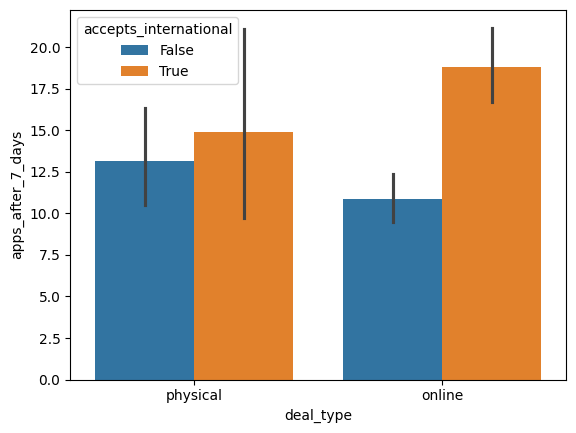

In [ ]:
# Check if the "International Boost" exists for Physical deals too
import seaborn as sns
sns.barplot(data=clean_df, x='deal_type',
            y='apps_after_7_days', hue='accepts_international')

In [ ]:
clean_df[
    (clean_df['deal_type'] == 'physical') &
    (clean_df['accepted_countries_set'].apply(
        lambda x: 'NLD' in x if isinstance(x, (set, frozenset)) else False))
].copy()

,created_at,updated_at,deleted_at,id,legacy_partner_id,deal_title,deal_text,creators_requirement,hash_tags,status,...,content_types_list,accepted_countries_set,company_locations_parsed,city_set,province_set,province_list,monthly_sums,rest_monthly_sums,log_rest_of_platform,log_deal_value
17,2025-09-03 20:28:54.617718,2026-01-12 07:39:16.894227,NaT,01991144-a1d9-00c8-d237-1aba7afc7e63,1290.0,Vrouwelijk model Ralph Lauren kleding,Timeless Treasury is dé webshop voor exclusiev...,Zie vacaturetekst,,live,...,"[Luxury, Lifestyle, Fashion]",{NLD},"[{'id': '01KERHW5HX05FXFSGB50HTS6B6', 'name': ...",(breda),(noord-brabant),[noord-brabant],4607,4572,8.427925,0.000000
43,2025-07-31 09:01:47.423425,2026-01-12 07:39:41.014016,NaT,01985fb7-561f-00c8-9275-2a7e0744a116,1695.0,5L Sangria met 5 vrienden!,Bij Tapasbar Plan B serveren wij een heerlijke...,Een foto of video van de sangria op je eigen I...,"#sangria,#tapas,#breda,#tapasbreda,#sangriabre...",live,...,"[Drinks, Food]",{NLD},"[{'id': '01KERJ076Q05FG96NKWD4X36GM', 'name': ...",(breda),(noord-brabant),[noord-brabant],4981,4972,8.511779,4.709530
85,2025-09-09 13:12:58.788668,2026-01-12 07:39:17.655011,NaT,01992e9b-aea4-00c8-f03d-ffdd3c477195,38.0,€50 Miniso Shoptegoed,Ontvang een waardebon van €50 om te besteden b...,– 1x Reel of TikTok van minimaal 30 seconden\n...,"#Miniso,#MinisoAlmere,#MinisoNetherlands",finished,...,[Lifestyle],{NLD},"[{'id': '01KERHTGYN05FQNT0YSK6QFQK2', 'name': ...",(almere),(flevoland),[flevoland],4607,4585,8.430763,NaN
86,2025-09-09 13:54:30.557941,2026-01-12 07:39:17.699821,NaT,01992ec1-b41d-00c8-a494-e382d81ba7f4,840.0,Microdermabrasie facial (goud) 60 min,oppervlaktereiniging - dieptereiniging met ski...,Bruikbare content voor onze eigen kanalen verz...,"#Gorinchem,#CleyoGorinchem,#cleyoskinexperts,#...",finished,...,[Beauty],{NLD},"[{'id': '01KERHWKGQ05FP3DBJXBBATN7R', 'name': ...",(gorinchem),(zuid-holland),[zuid-holland],4607,4597,8.433377,4.653960
103,2025-09-10 11:34:41.043316,2026-01-12 07:39:17.848545,NaT,01993368-0c93-00c8-a708-bc98087c28b5,258.0,Gratis Mogu Mogu en wordt betaald!,Wil jij gratis Mogu Mogu ontvangen en hiernaas...,Vereiste: Minimaal 8.000 volgers op TikTok en ...,"#MoguMogu,#Mogudrink",live,...,[Drinks],{NLD},"[{'id': '01KERHZ91305FVJKJJDA3H73SQ', 'name': ...",(noord-holland),(noord-holland),[noord-holland],4607,4583,8.430327,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6264,2025-07-30 12:36:23.619210,2026-01-12 07:39:40.403040,NaT,01985b55-73c3-00c8-d27d-c73704e22343,1427.0,Lunchen aan het strand voor 2 personen,"Geniet van onze verse lunchgerechten*, denk aa...",Een video op Instagram en/of Tiktok waarin je ...,"#Duneskijkduin,#kijkduin,#strand,#denhaaghotsp...",finished,...,"[Drinks, Food]",{NLD},"[{'id': '01KERHZNZH05FJ6GZGJGE8BBCQ', 'name': ...",(den haag),(zuid-holland),[zuid-holland],4981,4974,8.512181,NaN
6405,2025-09-05 12:52:47.469981,2026-01-12 07:39:17.411814,NaT,019919ef-c2ed-00c8-d53e-9a8d928d11bf,2366.0,€75 Streetwear & Vintage Store Voucher 2nd Cul...,We’re offering a €75 shopping voucher to spend...,We’re looking for creators who can capture the...,,draft,...,[Fashion],{NLD},"[{'id': '01KERHS82505FJ64ZW87B9Z0NR', 'name': ...",(amsterdam),(noord-holland),[noord-holland],4607,4600,8.434029,NaN
6415,2025-11-05 12:29:47.674253,2026-01-30 23:03:50.274103,NaT,019a53fe-a11a-00c8-34ff-50f99e73802a,159.0,white chocolate marshmellow special,1 december we are launching our white chocolat...,1 tiktok video or 1 instagram reel or 3 instag...,,finished,...,[Drinks],{NLD},"[{'id': '01KERHXNQC05FRAXKW1RDBCSVQ', 'name': ...",(noord-holland),(noord-holland),[noord-holland],6489,6474,8.775704,NaN
6449,2025-12-15 13:37:59.411365,2026-01-31 23:03:53.777266,NaT,019b223b-7073-00c8-d4c1-c48769a62cf2,1889.0,"Carbonara, elke woensdag bij Spaghetteria",***GOED LEZEN: \nWelkom bij Spaghetteria!\n\nE...,***GOED LEZEN: \nContent richtlijnen\nWe vinde...,#carbonara,finished,...,"[Drinks, Food]",{NLD},"[

In [73]:
physical_deals.province_set.value_counts()

province_set
(noord-holland)                                                                          55
(utrecht)                                                                                28
(noord-brabant)                                                                          25
(zuid-holland)                                                                           25
(groningen)                                                                               6
(gelderland)                                                                              6
(vlaams gewest)                                                                           5
(flevoland)                                                                               4
(hessen)                                                                                  3
(noord-holland, zuid-holland)                                                             3
(vlaanderen)                                                       

In [31]:
clean_df['province_set'].value_counts()

province_set
(noord-holland)                                                                          56
(utrecht)                                                                                29
(noord-brabant)                                                                          25
(zuid-holland)                                                                           25
(hessen)                                                                                 12
(groningen)                                                                               6
(gelderland)                                                                              6
(vlaams gewest)                                                                           5
(flevoland)                                                                               4
(noord-holland, zuid-holland)                                                             3
(vlaanderen)                                                       

In [29]:
clean_df['city_set'].value_counts()

city_set
(amsterdam)                                          26
(utrecht)                                            20
(breda)                                              14
(noord-holland)                                      10
(rotterdam)                                           9
                                                     ..
(rhenen)                                              1
(nijmegen)                                            1
(köln, amsterdam, karlsruhe, düsseldorf, detmold)     1
(land van cuijk)                                      1
(den haag, amsterdam, utrecht)                        1
Name: count, Length: 69, dtype: int64

In [ ]:
import pandas as pd

word_counts = df['deal_text'].str.split().explode().value_counts()
word_counts

deal_text
en                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

In [128]:
clean_df_zero_apps = clean_df[clean_df.applicants_applications_count == 0]
clean_df_zero_apps

,created_at,updated_at,deleted_at,id,legacy_partner_id,deal_title,deal_text,creators_requirement,hash_tags,status,...,planned_applications_count,rejected_applications_count,total_company_locations,upcoming_applications_count,first_content_type,apps_after_7_days,deal_language,days_since_start,month,log_deal_value
9,2025-12-30 09:24:39.120652,2026-01-12 07:39:41.019023,NaT,019b6e92-e450-00c8-ba72-bd31dc315002,3732.0,All Day Bites & Cocktails at Down Under,We nodigen je uit bij Down Under om onze nieuw...,In ruil vragen we om content die de ervaring b...,#downundernieuwegein,draft,...,0,0,1,0,UGC,0,nl,844,2025-12,3.931826
148,2026-01-15 07:44:26.839016,2026-01-15 07:44:26.839016,NaT,019bc09c-e6d6-00c8-3d56-efbda8bbf53a,NaN,Pijnvrij bewegen met de Daili Movement,"<p><strong style=""background-color: rgb(252, 2...",<p>Instagram&nbsp;reels&nbsp;voor&nbsp;META&nb...,"#livethedifference,#dailipharma,#dailimovement...",draft,...,0,0,0,0,Activities,0,nl,860,2026-01,4.330733
166,2025-09-11 08:48:26.809985,2026-01-12 07:39:18.304553,NaT,019937f6-36b9-00c8-4257-b1d8f39d3962,2449.0,Gratis Personal Training bij Staetsgeheim (€95),Ontvang een gratis personal training sessie t....,– 1x Reel of TikTok van minimaal 30 seconden w...,#staetsgeheim,draft,...,0,0,1,0,Activities,0,nl,734,2025-09,4.564348
170,2025-09-11 09:43:04.319889,2026-01-12 07:39:18.466273,NaT,01993828-397f-00c8-569c-56732ae0588c,2453.0,Holiday on Ice – 4 Tickets naar keuze (€140),Je ontvangt 4 tickets voor de spectaculaire ni...,– 1x Reel of TikTok vóór het event waarin je d...,#holidayonice,draft,...,0,0,1,0,Experiences,0,nl,734,2025-09,4.948760
214,2025-09-16 09:06:01.256789,2026-01-12 07:39:18.888358,NaT,019951c6-19a8-00c8-7883-5061d10bb250,2430.0,Healthy Feast at Avatars (€50) 🥗⚡️,You’ll receive €50 in-store credit at Avatars ...,– 1× reel or TikTok (≥ 30 sec) filmed on locat...,"#Avatars,#HealthyFastCasual,#BuildYourBowl,#Ea...",draft,...,0,0,1,0,UGC,0,en,739,2025-09,3.931826
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7224,2026-01-21 12:40:53.856660,2026-01-21 12:40:54.031874,NaT,019be092-7760-00c8-b3c6-d671b5f6ce17,NaN,Burger 'n Shake - 2x menu met loaded Fries & S...,<p>Bij&nbsp;<strong>Burger&nbsp;’n&nbsp;Shake<...,<p>📹&nbsp;<strong>1&nbsp;TikTok&nbsp;video</st...,#burgernshake,live,...,0,0,1,0,Activities,0,nl,867,2026-01,4.025352
7225,2026-01-21 12:43:31.402820,2026-01-21 13:57:55.625808,NaT,019be094-deca-00c8-2b27-55855d0c8e85,NaN,Burger 'n shake Leiden - 2x Menu met shake & f...,<p>Bij&nbsp;Burger&nbsp;’n&nbsp;Shake&nbsp;wer...,<p>📹&nbsp;1&nbsp;TikTok&nbsp;video&nbsp;</p><p...,#burgernshake,live,...,0,0,1,0,Activities,0,nl,867,2026-01,4.025352
7226,2026-01-21 12:43:52.298852,2026-01-21 13:56:41.808031,NaT,019be095-306a-00c8-a90b-ac9d47ab2178,NaN,Burger 'n shake Osdorp - 2x Menu met shake & f...,<p>Bij&nbsp;Burger&nbsp;’n&nbsp;Shake&nbsp;wer...,<p>📹&nbsp;1&nbsp;TikTok&nbsp;video&nbsp;</p><p...,#burgernshake,live,...,0,0,1,0,Activities,0,nl,867,2026-01,4.025352
7228,2026-01-21 13:46:10.497221,2026-01-26 09:54:51.283059,NaT,019be0ce-3ac1-00c8-947c-104f3bf0e318,NaN,1 maand gratis trainen bij I-Fitness 💪,<p>Je&nbsp;ontvangt&nbsp;1&nbsp;maand&nbsp;gra...,<p>–&nbsp;1×&nbsp;feed-video&nbsp;(≥&nbsp;30&n...,"#IFitness,#GymLife,#WorkoutMotivation,#Fitness...",draft,...,0,0,5,0,Luxury,0,nl,867,2026-01,4.094345


## Visualise over time

In [25]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Ensure datetime format
model_df['created_at'] = pd.to_datetime(model_df['created_at'])

# 2. Extract a numeric 'Time' feature for correlation (e.g., Days since start)
# We subtract the minimum date to get a "Day 0", "Day 1"... counter
# start_date = model_df['created_at'].min()
# og_df['days_since_start'] = (og_df['created_at'] - start_date).dt.days


def visualise_var_over_time(input_df, y_variable='apps_after_7_days', agg_type='sum'):

    # 3. Visualization: Two Views

    fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=False)

    # View A: Raw Scatter (The Noise)
    # We sample 2000 points if the dataset is huge to prevent overplotting
    plot_data = input_df.sample(n=min(2000, len(input_df)), random_state=42)
    sns.scatterplot(
        data=plot_data,
        x='created_at',
        y='apps_after_7_days',
        alpha=0.3,
        ax=axes[0]
    )
    axes[0].set_title("Raw Data: Applications over Time")
    axes[0].set_ylabel("Apps after 7 Days")

    # View B: Monthly Trend (The Signal)
    # Resample by Month to see if the AVERAGE deal is getting more apps
    monthly_trend = input_df.set_index('created_at').resample('M')[
        y_variable].agg([agg_type, 'count'])
    sns.lineplot(data=monthly_trend, x=monthly_trend.index,
                 y=agg_type, ax=axes[1], color='red', linewidth=2)
    axes[1].set_title(
        f"Platform Trend: {agg_type} Applications per Deal (Monthly)")
    axes[1].set_ylabel(f"{agg_type} Apps per Deal")
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

    # 4. Statistical Check
    # Correlation between Time and Applications
    corr = input_df[['days_since_start',
                     'apps_after_7_days']].corr().iloc[0, 1]
    print(f"Correlation between Time and Application Count: {corr:.4f}")

    # Check for "Deal Volume" dilution
    # (Sometimes apps per deal DROP if deal volume grows faster than user base)
    volume_corr = monthly_trend[agg_type].corr(monthly_trend['count'])
    print(
        f"Correlation between Monthly Deal Volume and {agg_type} of {y_variable}: {volume_corr:.4f}")

C:\Users\Wouter Barter\AppData\Local\Temp\ipykernel_20400\1573628054.py:35: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_trend = input_df.set_index('created_at').resample('M')[


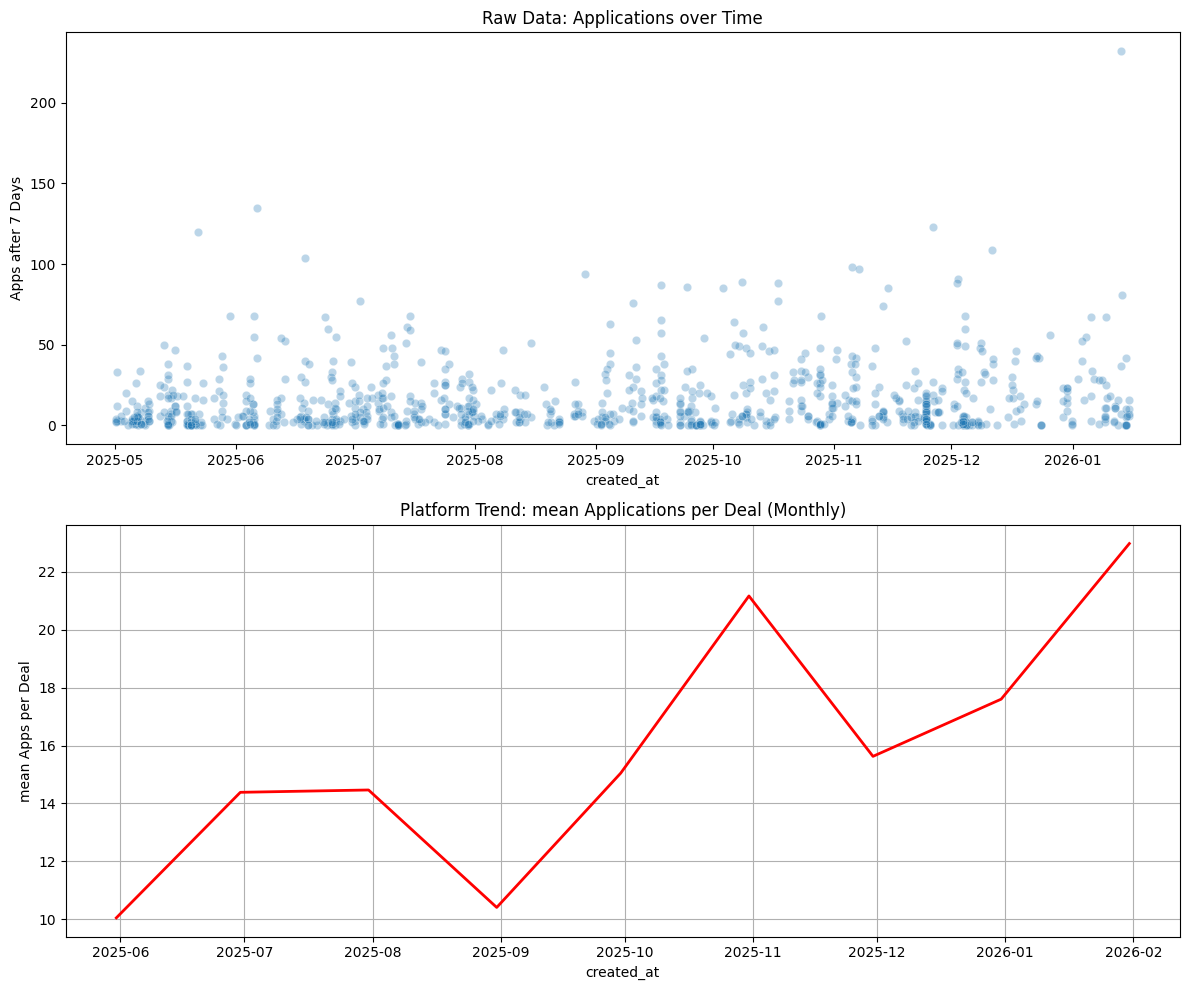

Correlation between Time and Application Count: 0.1319
Correlation between Monthly Deal Volume and mean of apps_after_7_days: -0.4326


In [ ]:
visualise_var_over_time(clean_df, agg_type='mean')

In [28]:
model_df['month'].value_counts()

month
2025-05    142
2025-07    135
2025-11    121
2025-09    119
2025-06    114
2025-12    106
2025-10    101
2025-08     61
2026-01     47
Freq: M, Name: count, dtype: int64

In [31]:
df['month'].value_counts()

month
2025-09    447
2025-07    438
2025-11    428
2025-06    423
2025-10    420
2025-05    419
2026-01    353
2025-03    342
2025-04    338
2025-02    330
2025-12    301
2025-08    293
2025-01    233
2024-11    212
2024-10    205
2024-12    191
2024-03    134
2024-09    129
2024-07    117
2024-05    111
2023-10    104
2024-02     85
2024-04     79
2024-06     78
2023-11     66
2024-08     60
2024-01     53
2023-09     44
2023-12     38
2026-02      1
Freq: M, Name: count, dtype: int64

In [29]:
model_df.groupby('month')['apps_after_7_days'].sum()

month
2025-05    1427
2025-06    1640
2025-07    1953
2025-08     635
2025-09    1791
2025-10    2138
2025-11    1891
2025-12    1866
2026-01    1080
Freq: M, Name: apps_after_7_days, dtype: int64

In [ ]:
mask = model_df['town_slug'].notna(
) & model_df['company_locations_parsed'].notna()
model_df[mask]

,created_at,updated_at,deleted_at,id,legacy_partner_id,deal_title,deal_text,creators_requirement,hash_tags,status,...,market_scope,log_desc_length,desc_length,deal_type_physical,deal_text_has_emoji,is_live,has_em_dash,deal_title_len,company_locations_parsed,town_slug
17,2025-09-03 20:28:54.617718,2026-01-12 07:39:16.894227,NaT,01991144-a1d9-00c8-d237-1aba7afc7e63,1290.0,Vrouwelijk model Ralph Lauren kleding,Timeless Treasury is dé webshop voor exclusiev...,Zie vacaturetekst,,live,...,Tier1_NL_Core,7.234898,1386,True,False,True,False,3.610918,"[{'id': '01KERHW5HX05FXFSGB50HTS6B6', 'name': ...",[Breda]
43,2025-07-31 09:01:47.423425,2026-01-12 07:39:41.014016,NaT,01985fb7-561f-00c8-9275-2a7e0744a116,1695.0,5L Sangria met 5 vrienden!,Bij Tapasbar Plan B serveren wij een heerlijke...,Een foto of video van de sangria op je eigen I...,"#sangria,#tapas,#breda,#tapasbreda,#sangriabre...",live,...,Tier1_NL_Core,5.683580,293,True,False,True,False,3.295837,"[{'id': '01KERJ076Q05FG96NKWD4X36GM', 'name': ...",[Breda]
85,2025-09-09 13:12:58.788668,2026-01-12 07:39:17.655011,NaT,01992e9b-aea4-00c8-f03d-ffdd3c477195,38.0,€50 Miniso Shoptegoed,Ontvang een waardebon van €50 om te besteden b...,– 1x Reel of TikTok van minimaal 30 seconden\n...,"#Miniso,#MinisoAlmere,#MinisoNetherlands",finished,...,Tier1_NL_Core,5.937536,378,True,False,False,False,3.044522,"[{'id': '01KERHTGYN05FQNT0YSK6QFQK2', 'name': ...",[Almere]
86,2025-09-09 13:54:30.557941,2026-01-12 07:39:17.699821,NaT,01992ec1-b41d-00c8-a494-e382d81ba7f4,840.0,Microdermabrasie facial (goud) 60 min,oppervlaktereiniging - dieptereiniging met ski...,Bruikbare content voor onze eigen kanalen verz...,"#Gorinchem,#CleyoGorinchem,#cleyoskinexperts,#...",finished,...,Tier1_NL_Core,5.568345,261,True,False,False,False,3.610918,"[{'id': '01KERHWKGQ05FP3DBJXBBATN7R', 'name': ...",[Gorinchem]
103,2025-09-10 11:34:41.043316,2026-01-12 07:39:17.848545,NaT,01993368-0c93-00c8-a708-bc98087c28b5,258.0,Gratis Mogu Mogu en wordt betaald!,Wil jij gratis Mogu Mogu ontvangen en hiernaas...,Vereiste: Minimaal 8.000 volgers op TikTok en ...,"#MoguMogu,#Mogudrink",live,...,Tier1_NL_Core,6.668228,786,True,False,True,False,3.526361,"[{'id': '01KERHZ91305FVJKJJDA3H73SQ', 'name': ...",[noord-holland]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6264,2025-07-30 12:36:23.619210,2026-01-12 07:39:40.403040,NaT,01985b55-73c3-00c8-d27d-c73704e22343,1427.0,Lunchen aan het strand voor 2 personen,"Geniet van onze verse lunchgerechten*, denk aa...",Een video op Instagram en/of Tiktok waarin je ...,"#Duneskijkduin,#kijkduin,#strand,#denhaaghotsp...",finished,...,Tier1_NL_Core,5.645447,282,True,False,False,False,3.663562,"[{'id': '01KERHZNZH05FJ6GZGJGE8BBCQ', 'name': ...",[Den Haag]
6405,2025-09-05 12:52:47.469981,2026-01-12 07:39:17.411814,NaT,019919ef-c2ed-00c8-d53e-9a8d928d11bf,2366.0,€75 Streetwear & Vintage Store Voucher 2nd Cul...,We’re offering a €75 shopping voucher to spend...,We’re looking for creators who can capture the...,,draft,...,Tier1_NL_Core,6.063785,429,True,False,False,False,3.912023,"[{'id': '01KERHS82505FJ64ZW87B9Z0NR', 'name': ...",[Amsterdam]
6415,2025-11-05 12:29:47.674253,2026-01-30 23:03:50.274103,NaT,019a53fe-a11a-00c8-34ff-50f99e73802a,159.0,white chocolate marshmellow special,1 december we are launching our white chocolat...,1 tiktok video or 1 instagram reel or 3 instag...,,finished,...,Tier1_NL_Core,5.505332,245,True,False,False,False,3.555348,"[{'id': '01KERHXNQC05FRAXKW1RDBCSVQ', 'name': ...",[noord-holland]
6449,2025-12-15 13:37:59.411365,2026-01-31 23:03:53.777266,NaT,019b223b-7073-00c8-d4c1-c48769a62cf2,1889.0,"Carbonara, elke woensdag bij Spaghetteria",***GOED LEZEN: \nWelkom bij Spaghetteria!\n\nE...,***GOED LEZEN: \nContent richtlijnen\nWe vinde...,#carbonara,finished,...,Tier1_NL_Core,6.342121,567,True,False,False,True,3.713572,"[{'id': '01KERHT3EG05FTSQ0Y5EHH2C44', 'name': ...","[Amsterdam, Amsterdam, Amsterdam, Amsterdam]"


# Notes

Interestingly, putting the value in title or text does not significantly drive applications.

In [ ]:
model_df['value_in_title'] = ["€" in x for x in model_df['deal_title']]
model_df['value_in_text'] = ["€" in x for x in model_df['deal_text']]
model_df['value_in_title_or_text'] = model_df['value_in_text'] | model_df['value_in_title']